# Module 08: Expression Variability Analysis

## Overview
This module examines transcriptional variability in senescent vs non-senescent cells and contextualizes senescence effects relative to other biological factors.

## Biological Questions
1. **What is the transcriptional signature of senescent cells?** (DEG summary)
2. **Do SnC cells show higher transcriptional variability than Non-SnC cells?** (CV analysis)
3. **What factors explain variance in gene expression?** (Variance partitioning)

## Workflow
- **08A**: DEG Summary Visualization (Figure 3A)
- **08B**: Coefficient of Variation Analysis
- **08C**: Variance Partitioning (Figure 3B)
- **08D**: Integrated Figure

---

In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-1: LIBRARIES
# ════════════════════════════════════════════════════════════════════════════════

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.sparse import issparse

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 10, 'axes.labelsize': 10, 'axes.titlesize': 11,
    'legend.fontsize': 9, 'font.family': 'sans-serif',
    'axes.linewidth': 1.0, 'axes.grid': False, 'pdf.fonttype': 42,
})
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=150, dpi_save=300, facecolor='white', frameon=False)

print("✓ Libraries loaded")

/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


✓ Libraries loaded


In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# 08A-2: CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════════

DATASET = "psychad_aging"
CELL_TYPE = "OPC"

# ─────────────────────────────────────────────────────────────────────────────────
# Dataset Config
# ─────────────────────────────────────────────────────────────────────────────────

STUDY_CONFIG = {
    'psychad_aging': {
        'type': 'aging',
        'primary_var': 'Age',
        'primary_var_type': 'continuous',
        'reference_group': 'Age_40_49',
        'covariates': ['Sex', 'Cohort'],
        'random_effect': 'Sample',
        'sex_col': 'Sex',
        'cohort_col': 'Cohort',
        'cell_type_col': 'subclass',
        'sample_col': 'Sample',
        'senescence_col': 'senescence_label',
        'study_group_col': 'Study_Group',
        'group_order': ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59',
                        'Age_60_69', 'Age_70_79', 'Age_80_100'],
    },
    'psychad_ad': {
        'type': 'disease',
        'primary_var': 'Disease_Group',
        'primary_var_type': 'categorical',
        'reference_group': 'Old_Healthy_Control',
        'covariates': ['Age', 'Sex', 'Cohort'],
        'random_effect': 'Sample',
        'sex_col': 'Sex',
        'cohort_col': 'Cohort',
        'cell_type_col': 'subclass',
        'sample_col': 'Sample',
        'senescence_col': 'senescence_label',
        'study_group_col': 'Disease_Group',
        'group_order': ['Young_Healthy_Control', 'Old_Healthy_Control', 'Old_AD'],
    },
    'psychencode': {
        'type': 'aging',
        'primary_var': 'Age_death',
        'primary_var_type': 'continuous',
        'reference_group': 'Age_40_49',
        'covariates': ['Biological_Sex', 'Cohort'],
        'random_effect': 'sample_id',
        'sex_col': 'Biological_Sex',
        'cohort_col': 'Cohort',
        'cell_type_col': 'cell_type',
        'sample_col': 'sample_id',
        'senescence_col': 'senescence_label',
        'study_group_col': 'Study_Group',
        'group_order': ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59',
                        'Age_60_69', 'Age_70_79', 'Age_80_100'],
    },
    'blood_itou': {
        'type': 'disease',
        'primary_var': 'disease state',
        'primary_var_type': 'categorical',
        'reference_group': 'Control',
        'covariates': ['Age', 'Sex'],
        'random_effect': 'Sample',
        'sex_col': 'Sex',
        'cohort_col': None,
        'cell_type_col': 'predicted.celltype.l1',
        'sample_col': 'Sample',
        'senescence_col': 'is_senescent',
        'study_group_col': 'disease state',
        'group_order': ['Control', 'Non-rapid ALS', 'Rapid ALS'],
    },
}

config = STUDY_CONFIG[DATASET]
STUDY_TYPE = config['type']
GROUP_ORDER = config['group_order']
CELL_TYPE_COL = config['cell_type_col']
SAMPLE_COL = config['sample_col']
SENESCENCE_COL = config['senescence_col']
STUDY_GROUP_COL = config['study_group_col']
REFERENCE_GROUP = config.get('reference_group', GROUP_ORDER[0])

# ─────────────────────────────────────────────────────────────────────────────────
# Colors
# ─────────────────────────────────────────────────────────────────────────────────

STUDY_GROUP_COLORS = {
    'Age_20_29': '#2E86AB', 'Age_30_39': '#4A90E2', 'Age_40_49': '#50C878',
    'Age_50_59': '#FFB347', 'Age_60_69': '#FF8C00', 'Age_70_79': '#E24A4A',
    'Age_80_100': '#8B0000',
    'Young_Healthy_Control': '#4E79A7', 'Old_Healthy_Control': '#59A14F', 'Old_AD': '#E15759',
    'Control': '#4E79A7', 'MCI': '#F28E2B', 'AD': '#E15759', 'NCI': '#4E79A7',
    'Non-rapid ALS': '#F28E2B', 'Rapid ALS': '#E15759',
}

SNC_COLORS = {"SnC": "#D73027", "Non-SnC": "#BDBDBD"}

CELL_TYPE_COLORS = {
    'Microglia': '#EDC948', 'Astrocyte': '#E15759', 'OPC': '#59A14F',
    'Oligodendrocyte': '#76B7B2', 'Excitatory': '#4E79A7',
    'Inhibitory': '#F28E2B', 'Endothelial': '#B07AA1',
    'Mono': '#4E79A7', 'NK': '#F28E2B', 'B': '#E15759',
    'CD4 T': '#76B7B2', 'CD8 T': '#59A14F',
    'DC': '#B07AA1', 'other T': '#EDC948', 'other': '#BAB0AC',
}

SEX_COLORS = {
    'Male': '#5D6D7E', 'Female': '#A569BD',
    'M': '#5D6D7E', 'F': '#A569BD',
}

# ─────────────────────────────────────────────────────────────────────────────────
# Paths
# ─────────────────────────────────────────────────────────────────────────────────

BASE_DIR = Path("/fs/scratch/PAS2598/senescence_analysis")

SC_FILE = BASE_DIR / "data" / "04_subsetting" / DATASET / f"{DATASET}_celltypes_subset.h5ad"

DEG_RESULTS_DIR = BASE_DIR / "results" / "05_deg" / DATASET / CELL_TYPE.lower()
RESULTS_DIR = BASE_DIR / "results" / "08_variability" / DATASET / CELL_TYPE.lower()
FIGURES_DIR = BASE_DIR / "figures" / "08_variability" / DATASET / CELL_TYPE.lower()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────────
# Thresholds
# ─────────────────────────────────────────────────────────────────────────────────

FDR_THRESHOLD = 0.05
LFC_THRESHOLD = 0.5

# ─────────────────────────────────────────────────────────────────────────────────
# Print
# ─────────────────────────────────────────────────────────────────────────────────

print("=" * 80)
print(f"Dataset:        {DATASET}")
print(f"Cell type:      {CELL_TYPE}")
print(f"Study type:     {STUDY_TYPE}")
print(f"Reference:      {REFERENCE_GROUP}")
print(f"Group order:    {GROUP_ORDER}")
print(f"SC file:        {SC_FILE.name}")
print(f"DEG results:    {DEG_RESULTS_DIR}")
print(f"Results:        {RESULTS_DIR}")
print(f"Figures:        {FIGURES_DIR}")
print(f"Senescence col: {SENESCENCE_COL}")
print(f"Cell type col:  {CELL_TYPE_COL}")
print(f"Sample col:     {SAMPLE_COL}")
print("=" * 80)

Dataset:        psychad_aging
Cell type:      OPC
Study type:     aging
Reference:      Age_40_49
Group order:    ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']
SC file:        psychad_aging_celltypes_subset.h5ad
DEG results:    /fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging/opc
Results:        /fs/scratch/PAS2598/senescence_analysis/results/08_variability/psychad_aging/opc
Figures:        /fs/scratch/PAS2598/senescence_analysis/figures/08_variability/psychad_aging/opc
Senescence col: senescence_label
Cell type col:  subclass
Sample col:     Sample


---

## Load Data

In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("LOAD DATA")
print("=" * 60)

adata_all = sc.read_h5ad(SC_FILE)
print(f"  Total cells: {adata_all.n_obs:,} x {adata_all.n_vars:,} genes")

# Subset to cell type
adata = adata_all[adata_all.obs[CELL_TYPE_COL] == CELL_TYPE].copy()
print(f"  {CELL_TYPE} cells: {adata.n_obs:,}")

# Ensure senescence column is boolean
if adata.obs[SENESCENCE_COL].dtype == 'object' or adata.obs[SENESCENCE_COL].dtype.name == 'category':
    adata.obs['is_senescent'] = adata.obs[SENESCENCE_COL].map(
        {1: True, 0: False, '1': True, '0': False, True: True, False: False,
         'True': True, 'False': False, 'SnC': True, 'Non-SnC': False}
    ).fillna(False).astype(bool)
else:
    adata.obs['is_senescent'] = adata.obs[SENESCENCE_COL].astype(bool)

n_snc = adata.obs['is_senescent'].sum()
n_nonsnc = (~adata.obs['is_senescent']).sum()
print(f"\n  SnC:     {n_snc:,} ({100*n_snc/len(adata):.1f}%)")
print(f"  Non-SnC: {n_nonsnc:,} ({100*n_nonsnc/len(adata):.1f}%)")
print(f"  Imbalance ratio: {n_nonsnc/max(n_snc,1):.1f}x")

# Study groups
print(f"\n  Study groups:")
for g in GROUP_ORDER:
    n = (adata.obs[STUDY_GROUP_COL] == g).sum()
    if n > 0:
        print(f"    {g}: {n:,}")

# Donors
print(f"\n  Donors: {adata.obs[SAMPLE_COL].nunique()}")

LOAD DATA
  Total cells: 99,717 x 34,890 genes
  OPC cells: 36,059

  SnC:     2,726 (7.6%)
  Non-SnC: 33,333 (92.4%)
  Imbalance ratio: 12.2x

  Study groups:
    Age_20_29: 6,635
    Age_30_39: 5,064
    Age_40_49: 6,969
    Age_50_59: 4,745
    Age_60_69: 4,365
    Age_70_79: 4,820
    Age_80_100: 3,461

  Donors: 124


---

## Imbalance Assessment

Check SnC vs Non-SnC counts per donor before balancing.

In [4]:
# ════════════════════════════════════════════════════════════════════════════════
# IMBALANCE ASSESSMENT
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("IMBALANCE ASSESSMENT")
print("=" * 60)

counts = adata.obs.groupby([SAMPLE_COL, 'is_senescent']).size().unstack(fill_value=0)
counts.columns = ['Non-SnC', 'SnC']
counts['total'] = counts.sum(axis=1)
counts['ratio'] = counts['Non-SnC'] / counts['SnC'].replace(0, np.nan)

print(f"\n  Per-donor summary:")
print(f"    Donors with both SnC & Non-SnC: {counts['SnC'].gt(0).sum()} / {len(counts)}")
print(f"    Median SnC per donor: {counts['SnC'].median():.0f}")
print(f"    Median Non-SnC per donor: {counts['Non-SnC'].median():.0f}")
print(f"    Median imbalance ratio: {counts['ratio'].median():.1f}x")

print(f"\n  {'Donor':<12} {'Non-SnC':>8} {'SnC':>6} {'Ratio':>8}")
print(f"  {'─'*38}")
for donor, row in counts.sort_values('ratio', ascending=False).iterrows():
    ratio_str = f"{row['ratio']:.1f}x" if not np.isnan(row['ratio']) else "inf"
    print(f"  {str(donor):<12} {row['Non-SnC']:>8,.0f} {row['SnC']:>6,.0f} {ratio_str:>8}")

IMBALANCE ASSESSMENT

  Per-donor summary:
    Donors with both SnC & Non-SnC: 115 / 124
    Median SnC per donor: 12
    Median Non-SnC per donor: 238
    Median imbalance ratio: 14.9x

  Donor         Non-SnC    SnC    Ratio
  ──────────────────────────────────────
  AMPAD_HBCC_0000000129      308      1   308.0x
  AMPAD_MSSM_0000063628      243      1   243.0x
  AMPAD_HBCC_0000000125      903      4   225.8x
  AMPAD_HBCC_0000000174      446      2   223.0x
  AMPAD_HBCC_0000000207      541      3   180.3x
  AMPAD_HBCC_0000000373      466      4   116.5x
  AMPAD_HBCC_0000000062      448      4   112.0x
  AMPAD_HBCC_0000000226      528      5   105.6x
  AMPAD_HBCC_0000000128      727      7   103.9x
  AMPAD_HBCC_0000000010      311      3   103.7x
  AMPAD_MSSM_0000056469      203      2   101.5x
  AMPAD_MSSM_0000076268      189      2    94.5x
  AMPAD_HBCC_0000000065      624      7    89.1x
  AMPAD_MSSM_0000037941      246      3    82.0x
  AMPAD_MSSM_0000282520      162      2    81.

/tmp/ipykernel_1376559/95294886.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata.obs.groupby([SAMPLE_COL, 'is_senescent']).size().unstack(fill_value=0)


In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# BALANCED SUBSAMPLING
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("BALANCED SUBSAMPLING")
print("=" * 60)

MIN_CELLS_PER_GROUP = 20
np.random.seed(42)

keep_indices = []
skipped_donors = []

for donor, group_df in adata.obs.groupby(SAMPLE_COL):
    snc_idx = group_df[group_df['is_senescent'] == True].index
    nonsnc_idx = group_df[group_df['is_senescent'] == False].index

    n_min = min(len(snc_idx), len(nonsnc_idx))

    if n_min < MIN_CELLS_PER_GROUP:
        skipped_donors.append({'Donor': donor, 'n_snc': len(snc_idx), 'n_nonsnc': len(nonsnc_idx)})
        continue

    sampled_snc = np.random.choice(snc_idx, n_min, replace=False)
    sampled_nonsnc = np.random.choice(nonsnc_idx, n_min, replace=False)

    keep_indices.extend(sampled_snc)
    keep_indices.extend(sampled_nonsnc)

adata_balanced = adata[keep_indices].copy()

print(f"\n  Original:  {adata.n_obs:,} cells")
print(f"  Balanced:  {adata_balanced.n_obs:,} cells")
print(f"  Retained:  {100*adata_balanced.n_obs/adata.n_obs:.1f}%")

n_snc_bal = adata_balanced.obs['is_senescent'].sum()
n_nonsnc_bal = (~adata_balanced.obs['is_senescent']).sum()
print(f"\n  SnC:       {n_snc_bal:,}")
print(f"  Non-SnC:   {n_nonsnc_bal:,}")
print(f"  Balanced:  {'✓' if n_snc_bal == n_nonsnc_bal else '✗'}")

n_donors_kept = adata_balanced.obs[SAMPLE_COL].nunique()
print(f"\n  Donors kept:    {n_donors_kept}")
print(f"  Donors skipped: {len(skipped_donors)}")

if skipped_donors:
    print(f"\n  Skipped (< {MIN_CELLS_PER_GROUP} SnC):")
    for d in skipped_donors:
        print(f"    {d['Donor']}: {d['n_snc']} SnC, {d['n_nonsnc']} Non-SnC")

BALANCED SUBSAMPLING


/tmp/ipykernel_1376559/41114846.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for donor, group_df in adata.obs.groupby(SAMPLE_COL):



  Original:  36,059 cells
  Balanced:  4,428 cells
  Retained:  12.3%

  SnC:       2,214
  Non-SnC:   2,214
  Balanced:  ✓

  Donors kept:    50
  Donors skipped: 74

  Skipped (< 20 SnC):
    AMPAD_HBCC_0000000004: 8 SnC, 77 Non-SnC
    AMPAD_HBCC_0000000010: 3 SnC, 311 Non-SnC
    AMPAD_HBCC_0000000027: 4 SnC, 103 Non-SnC
    AMPAD_HBCC_0000000054: 9 SnC, 124 Non-SnC
    AMPAD_HBCC_0000000061: 19 SnC, 386 Non-SnC
    AMPAD_HBCC_0000000062: 4 SnC, 448 Non-SnC
    AMPAD_HBCC_0000000065: 7 SnC, 624 Non-SnC
    AMPAD_HBCC_0000000076: 10 SnC, 214 Non-SnC
    AMPAD_HBCC_0000000080: 7 SnC, 326 Non-SnC
    AMPAD_HBCC_0000000082: 9 SnC, 285 Non-SnC
    AMPAD_HBCC_0000000084: 0 SnC, 1 Non-SnC
    AMPAD_HBCC_0000000088: 0 SnC, 311 Non-SnC
    AMPAD_HBCC_0000000089: 10 SnC, 72 Non-SnC
    AMPAD_HBCC_0000000092: 0 SnC, 543 Non-SnC
    AMPAD_HBCC_0000000100: 5 SnC, 198 Non-SnC
    AMPAD_HBCC_0000000103: 11 SnC, 440 Non-SnC
    AMPAD_HBCC_0000000107: 8 SnC, 164 Non-SnC
    AMPAD_HBCC_0000000110: 

In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# VERIFY BALANCE PER DONOR
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("BALANCE VERIFICATION")
print("=" * 60)

balance_check = (
    adata_balanced.obs.groupby([SAMPLE_COL, 'is_senescent'])
    .size().unstack(fill_value=0)
)
balance_check.columns = ['Non-SnC', 'SnC']
balance_check['equal'] = balance_check['Non-SnC'] == balance_check['SnC']

print(f"\n  {'Donor':<12} {'Non-SnC':>8} {'SnC':>6} {'Balanced':>8}")
print(f"  {'─'*38}")
for donor, row in balance_check.iterrows():
    check = "✓" if row['equal'] else "✗"
    print(f"  {str(donor):<12} {row['Non-SnC']:>8} {row['SnC']:>6} {check:>8}")

n_perfect = balance_check['equal'].sum()
print(f"\n  Perfectly balanced: {n_perfect} / {len(balance_check)} donors")
print(f"  Total SnC = {balance_check['SnC'].sum()}, Total Non-SnC = {balance_check['Non-SnC'].sum()}")

# Study group distribution in balanced set
print(f"\n  Study groups in balanced set:")
for g in GROUP_ORDER:
    n = (adata_balanced.obs[STUDY_GROUP_COL] == g).sum()
    nd = adata_balanced.obs[adata_balanced.obs[STUDY_GROUP_COL] == g][SAMPLE_COL].nunique()
    if n > 0:
        print(f"    {g}: {n:,} cells, {nd} donors")

BALANCE VERIFICATION

  Donor         Non-SnC    SnC Balanced
  ──────────────────────────────────────
  AMPAD_HBCC_0000000006       25     25        ✓
  AMPAD_HBCC_0000000008       51     51        ✓
  AMPAD_HBCC_0000000039       58     58        ✓
  AMPAD_HBCC_0000000050       21     21        ✓
  AMPAD_HBCC_0000000059       21     21        ✓
  AMPAD_HBCC_0000000075       21     21        ✓
  AMPAD_HBCC_0000000079       20     20        ✓
  AMPAD_HBCC_0000000096       35     35        ✓
  AMPAD_HBCC_0000000097       25     25        ✓
  AMPAD_HBCC_0000000126       31     31        ✓
  AMPAD_HBCC_0000000138       23     23        ✓
  AMPAD_HBCC_0000000171       99     99        ✓
  AMPAD_HBCC_0000000188       21     21        ✓
  AMPAD_HBCC_0000000206      112    112        ✓
  AMPAD_HBCC_0000000212       39     39        ✓
  AMPAD_HBCC_0000000229       21     21        ✓
  AMPAD_HBCC_0000000269       65     65        ✓
  AMPAD_HBCC_0000000274       33     33        ✓
  AMPAD_HBCC_00

/tmp/ipykernel_1376559/3256425068.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_balanced.obs.groupby([SAMPLE_COL, 'is_senescent'])


In [7]:
balance_check = (
    adata_balanced.obs.groupby([SAMPLE_COL, 'is_senescent'], observed=True)
    .size().unstack(fill_value=0)
)

adata.X = adata.layers['lognorm']

---

## Load DEG Results

In [8]:
# ════════════════════════════════════════════════════════════════════════════════
# LOAD DEG RESULTS
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("LOAD DEG RESULTS")
print("=" * 60)

# List available comparisons
deg_files = list(DEG_RESULTS_DIR.glob("*.csv"))
deg_files = [f for f in deg_files if not any(x in f.name for x in ["summary", "gsea", "genes", "pseudobulk"])]

print("Available comparisons:")
for f in deg_files:
    print(f"  • {f.name}")

# Select comparison
COMPARISON = "SnCvsNonSnC_all"
deg_file = DEG_RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_{COMPARISON}.csv"

if deg_file.exists():
    deg_data = pd.read_csv(deg_file)
    print(f"\n  Loaded: {COMPARISON}")
    print(f"  Total genes tested: {len(deg_data):,}")

    # Ensure direction column
    if "direction" not in deg_data.columns:
        deg_data["significant"] = (
            (deg_data["p_val_adj"] < FDR_THRESHOLD) &
            (deg_data["avg_log2FC"].abs() > LFC_THRESHOLD)
        )
        deg_data["direction"] = "NS"
        deg_data.loc[deg_data["significant"] & (deg_data["avg_log2FC"] > LFC_THRESHOLD), "direction"] = "Up"
        deg_data.loc[deg_data["significant"] & (deg_data["avg_log2FC"] < -LFC_THRESHOLD), "direction"] = "Down"

    n_up = (deg_data["direction"] == "Up").sum()
    n_down = (deg_data["direction"] == "Down").sum()

    print(f"\n  DEG Summary:")
    print(f"    Up in SnC:   {n_up}")
    print(f"    Down in SnC: {n_down}")
    print(f"    Total DEGs:  {n_up + n_down}")

    HAS_DEG = True
else:
    print(f"\n  ⚠ DEG file not found: {deg_file.name}")
    print(f"  Skipping DEG-dependent analyses")
    HAS_DEG = False

LOAD DEG RESULTS
Available comparisons:
  • psychad_aging_opc_SnCvsNonSnC_Old.csv
  • psychad_aging_opc_OldvsYoung_NonSnC.csv
  • psychad_aging_opc_OldvsYoung_all.csv
  • psychad_aging_opc_SnCvsNonSnC_all.csv
  • psychad_aging_opc_OldvsYoung_SnC.csv
  • psychad_aging_opc_SnCvsNonSnC_Young.csv

  Loaded: SnCvsNonSnC_all
  Total genes tested: 12,673

  DEG Summary:
    Up in SnC:   318
    Down in SnC: 45
    Total DEGs:  363


---

## DEG Summary Visualization

DEG VISUALIZATION


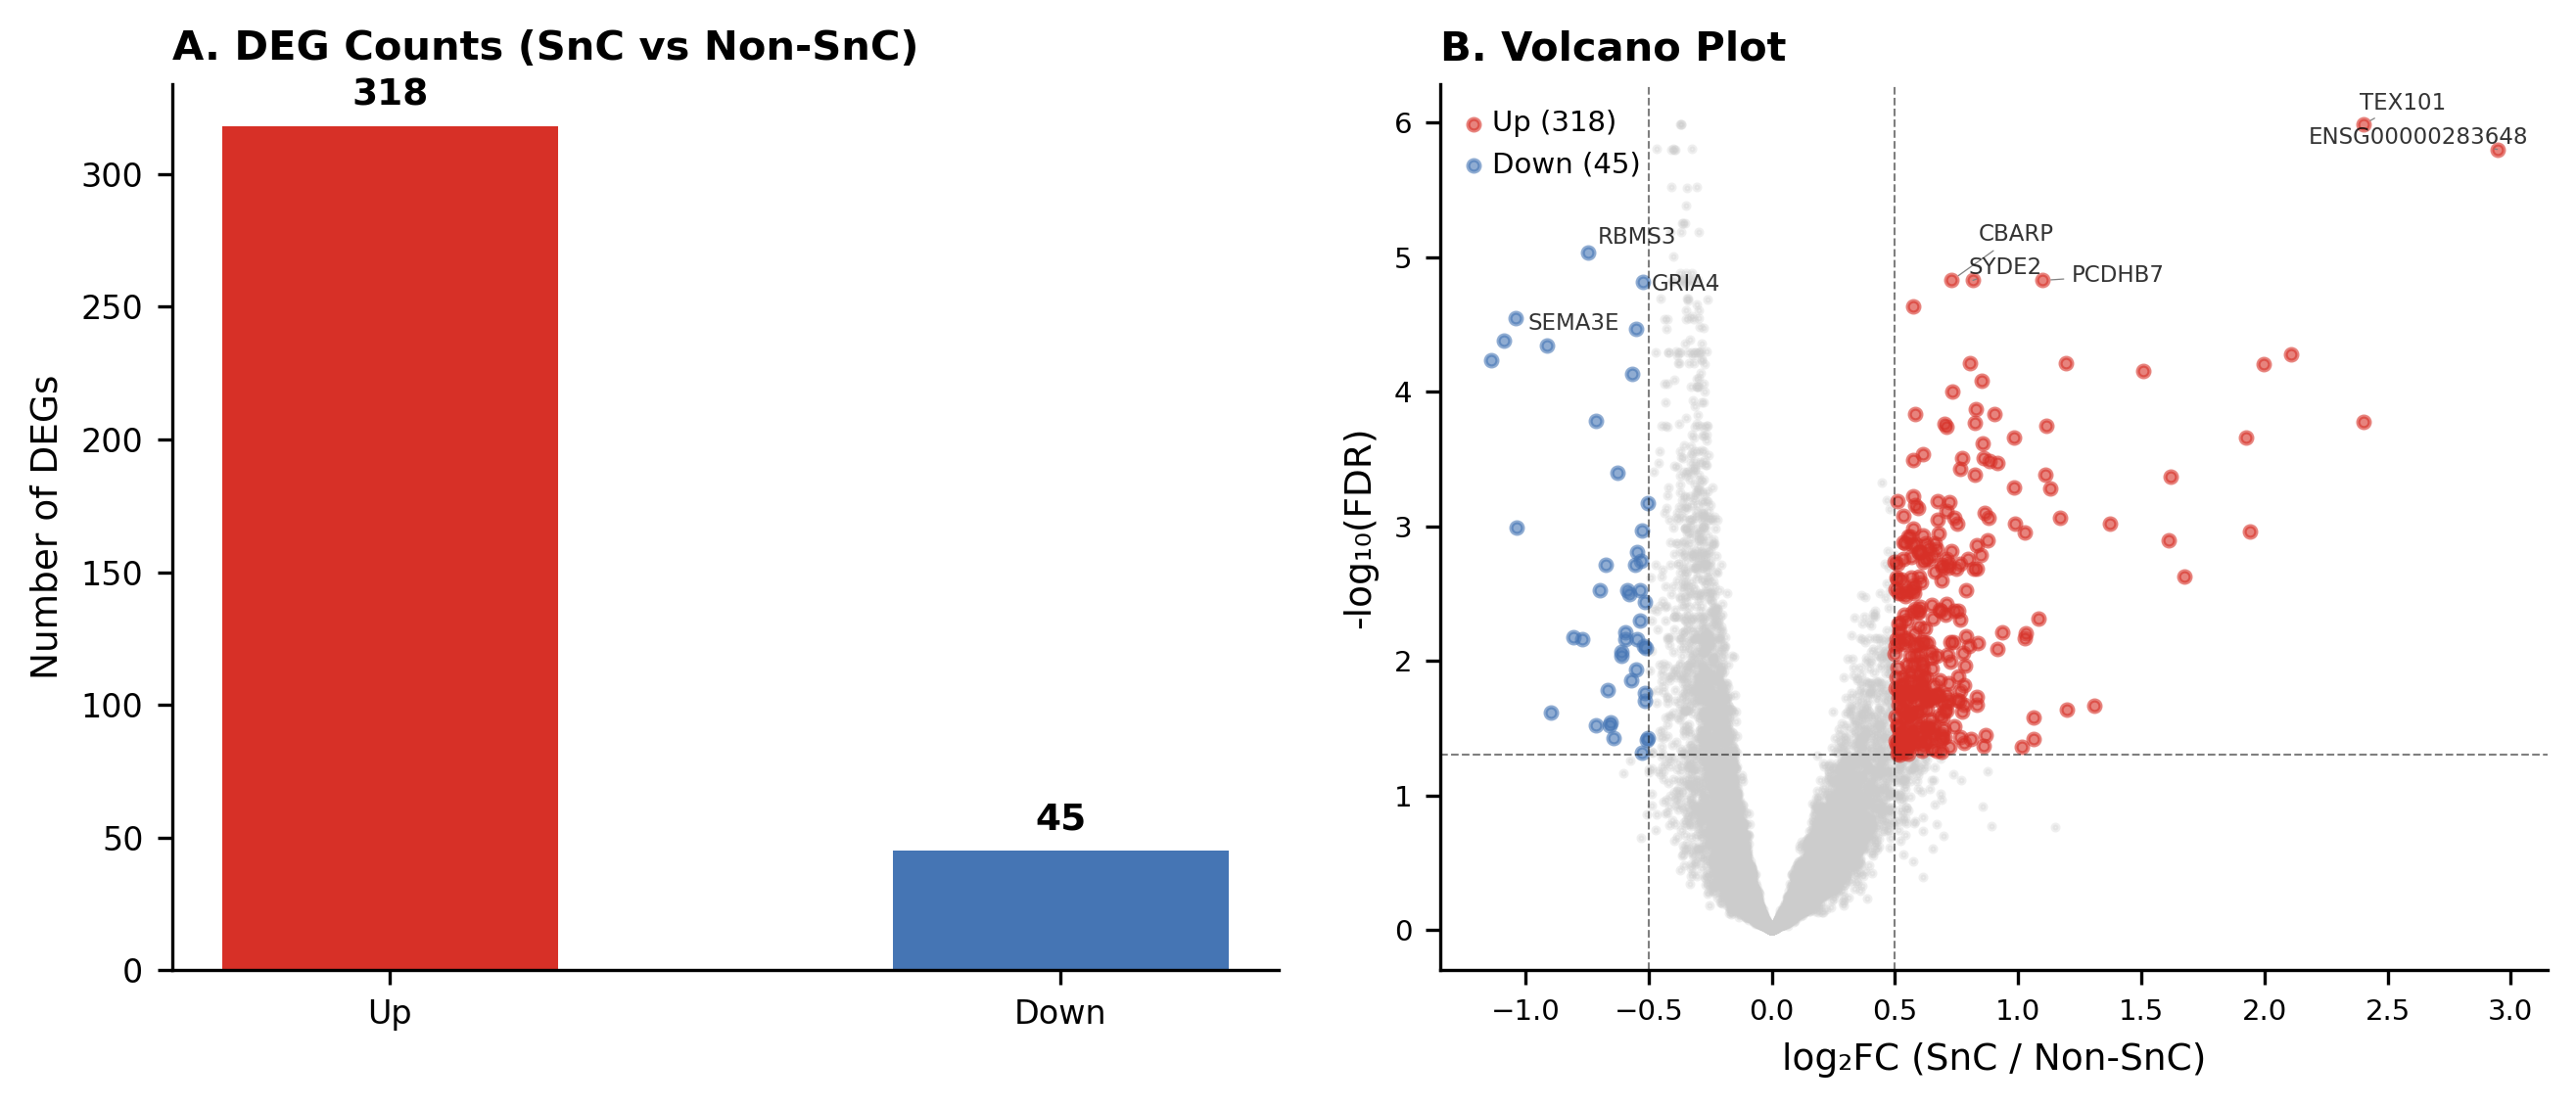

Saved DEG summary figure


In [9]:
# ════════════════════════════════════════════════════════════════════════════════
# DEG BAR PLOT + VOLCANO
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("DEG VISUALIZATION")
print("=" * 60)

if HAS_DEG:
    try:
        from adjustText import adjust_text
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "adjustText", "-q"])
        from adjustText import adjust_text

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    # ── Panel A: Bar plot ──
    ax = axes[0]
    ax.grid(False)
    bars = ax.bar(['Up', 'Down'], [n_up, n_down], color=['#D73027', '#4575B4'],
                  edgecolor='none', width=0.5)
    for bar, count in zip(bars, [n_up, n_down]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_ylabel('Number of DEGs', fontsize=9)
    ax.set_title('A. DEG Counts (SnC vs Non-SnC)', fontsize=10, fontweight='bold', loc='left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)

    # ── Panel B: Volcano ──
    ax = axes[1]
    ax.grid(False)

    deg_plot = deg_data.copy()
    deg_plot['-log10p'] = -np.log10(deg_plot['p_val_adj'].clip(lower=1e-300))

    # NS points
    ns = deg_plot[deg_plot['direction'] == 'NS']
    ax.scatter(ns['avg_log2FC'], ns['-log10p'], s=2, c='#CCCCCC', alpha=0.3, rasterized=True)

    # Up
    up = deg_plot[deg_plot['direction'] == 'Up']
    ax.scatter(up['avg_log2FC'], up['-log10p'], s=8, c='#D73027', alpha=0.6, label=f'Up ({n_up})')

    # Down
    down = deg_plot[deg_plot['direction'] == 'Down']
    ax.scatter(down['avg_log2FC'], down['-log10p'], s=8, c='#4575B4', alpha=0.6, label=f'Down ({n_down})')

    # Thresholds
    ax.axhline(-np.log10(FDR_THRESHOLD), color='k', linestyle='--', lw=0.5, alpha=0.5)
    ax.axvline(LFC_THRESHOLD, color='k', linestyle='--', lw=0.5, alpha=0.5)
    ax.axvline(-LFC_THRESHOLD, color='k', linestyle='--', lw=0.5, alpha=0.5)

    # Label top genes
    if 'gene' in deg_plot.columns:
        gene_col = 'gene'
    elif deg_plot.index.name:
        deg_plot['gene'] = deg_plot.index
        gene_col = 'gene'
    else:
        gene_col = None

    if gene_col:
        top_genes = pd.concat([
            up.nlargest(5, '-log10p'),
            down.nlargest(3, '-log10p'),
        ])
        texts = []
        for _, row in top_genes.iterrows():
            texts.append(ax.text(row['avg_log2FC'], row['-log10p'], row[gene_col],
                                 fontsize=5.5, alpha=0.8))
        if texts:
            adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.3))

    ax.set_xlabel('log₂FC (SnC / Non-SnC)', fontsize=9)
    ax.set_ylabel('-log₁₀(FDR)', fontsize=9)
    ax.set_title('B. Volcano Plot', fontsize=10, fontweight='bold', loc='left')
    ax.legend(fontsize=7, frameon=False, loc='upper left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_deg_summary.png', dpi=300, bbox_inches='tight')
    plt.savefig(FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_deg_summary.svg', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved DEG summary figure")
else:
    print("  Skipped — no DEG data")

---

## Donor-Level UMI by Senescence

Check if SnC cells have systematically different library sizes.

DONOR-LEVEL UMI STATS

  Median UMI (SnC):     12,198
  Median UMI (Non-SnC): 8,895
  Wilcoxon paired: p = 5.45e-13


/tmp/ipykernel_1376559/2760959558.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=donor_stats, x='Senescence', y='median_UMI',
/tmp/ipykernel_1376559/2760959558.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=donor_stats, x='Senescence', y='median_UMI',


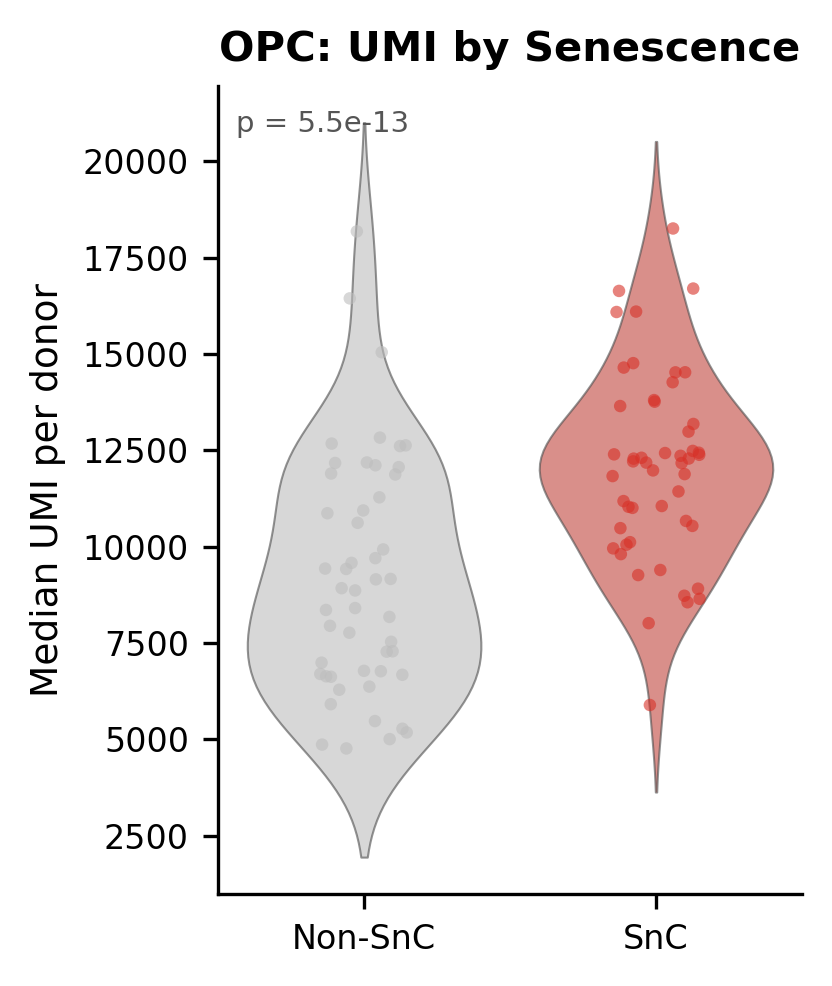

Saved UMI violin figure


In [10]:
# ════════════════════════════════════════════════════════════════════════════════
# DONOR-LEVEL UMI STATS
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("DONOR-LEVEL UMI STATS")
print("=" * 60)

from scipy.stats import wilcoxon

donor_stats = []

for donor in adata_balanced.obs[SAMPLE_COL].unique():
    donor_mask = adata_balanced.obs[SAMPLE_COL] == donor
    study_group = adata_balanced.obs.loc[donor_mask, STUDY_GROUP_COL].iloc[0]

    for is_snc in [True, False]:
        cell_mask = donor_mask & (adata_balanced.obs['is_senescent'] == is_snc)
        n_cells = cell_mask.sum()
        if n_cells == 0:
            continue

        if 'total_counts' in adata_balanced.obs.columns:
            median_umi = adata_balanced.obs.loc[cell_mask, 'total_counts'].median()
            mean_umi = adata_balanced.obs.loc[cell_mask, 'total_counts'].mean()
        else:
            median_umi = np.nan
            mean_umi = np.nan

        donor_stats.append({
            'donor': donor,
            'Study_Group': study_group,
            'Senescence': 'SnC' if is_snc else 'Non-SnC',
            'n_cells': n_cells,
            'median_UMI': median_umi,
            'mean_UMI': mean_umi,
        })

donor_stats = pd.DataFrame(donor_stats)

pivot_umi = donor_stats.pivot(index='donor', columns='Senescence', values='median_UMI').dropna()
stat_umi, pval_umi = wilcoxon(pivot_umi['SnC'], pivot_umi['Non-SnC'])

print(f"\n  Median UMI (SnC):     {pivot_umi['SnC'].median():,.0f}")
print(f"  Median UMI (Non-SnC): {pivot_umi['Non-SnC'].median():,.0f}")
print(f"  Wilcoxon paired: p = {pval_umi:.2e}")

# Figure
fig, ax = plt.subplots(figsize=(3, 3.5))
ax.grid(False)

sns.violinplot(data=donor_stats, x='Senescence', y='median_UMI',
               order=['Non-SnC', 'SnC'], palette=SNC_COLORS,
               inner=None, linewidth=0.5, alpha=0.6, ax=ax)
sns.stripplot(data=donor_stats, x='Senescence', y='median_UMI',
              order=['Non-SnC', 'SnC'], palette=SNC_COLORS,
              size=3, alpha=0.6, jitter=0.15, ax=ax)

ax.set_ylabel('Median UMI per donor', fontsize=9)
ax.set_xlabel('')
ax.set_title(f'{CELL_TYPE}: UMI by Senescence', fontsize=10, fontweight='bold')
ax.text(0.03, 0.97, f'p = {pval_umi:.1e}', transform=ax.transAxes,
        fontsize=7, ha='left', va='top', color='#555')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_umi_violin.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_umi_violin.svg', dpi=300, bbox_inches='tight')
plt.show()
print("Saved UMI violin figure")

---

## Gene-Level CV Analysis (Stratified by DEG Status)

Compute CV per gene, stratified by Up/Down/NS DEG categories. Tests whether transcriptional variability differs between SnC and Non-SnC specifically among differentially expressed genes.

In [11]:
# ════════════════════════════════════════════════════════════════════════════════
# GENE-LEVEL CV: STRATIFIED BY DEG STATUS
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("GENE-LEVEL CV (DEG-STRATIFIED)")
print("=" * 60)

# Set expression matrix
if 'log_normalized' in adata_balanced.layers:
    adata_balanced.X = adata_balanced.layers['log_normalized'].copy()
    print("  Set X = log_normalized")
elif 'lognorm' in adata_balanced.layers:
    adata_balanced.X = adata_balanced.layers['lognorm'].copy()
    print("  Set X = lognorm")
else:
    print(f"  Using existing X | Layers: {list(adata_balanced.layers.keys())}")

# Split by senescence
snc_mask = adata_balanced.obs['is_senescent'].values
nonsnc_mask = ~snc_mask

X_snc = adata_balanced.X[snc_mask]
X_nonsnc = adata_balanced.X[nonsnc_mask]

if issparse(X_snc):
    X_snc = X_snc.toarray()
    X_nonsnc = X_nonsnc.toarray()

print(f"\n  SnC cells:     {X_snc.shape[0]:,}")
print(f"  Non-SnC cells: {X_nonsnc.shape[0]:,}")
print(f"  Genes:         {X_snc.shape[1]:,}")

# Compute CV per gene
mean_snc = X_snc.mean(axis=0)
std_snc = X_snc.std(axis=0)
mean_nonsnc = X_nonsnc.mean(axis=0)
std_nonsnc = X_nonsnc.std(axis=0)

MIN_MEAN = 0.01
valid_mask = (mean_snc > MIN_MEAN) & (mean_nonsnc > MIN_MEAN)

cv_data = pd.DataFrame({
    'gene': adata_balanced.var_names,
    'mean_SnC': mean_snc,
    'mean_NonSnC': mean_nonsnc,
    'cv_SnC': np.where(valid_mask, std_snc / mean_snc, np.nan),
    'cv_NonSnC': np.where(valid_mask, std_nonsnc / mean_nonsnc, np.nan),
}).dropna(subset=['cv_SnC', 'cv_NonSnC'])

cv_data['cv_diff'] = cv_data['cv_SnC'] - cv_data['cv_NonSnC']
cv_data['cv_ratio'] = cv_data['cv_SnC'] / cv_data['cv_NonSnC']

print(f"  Genes with mean > {MIN_MEAN}: {len(cv_data):,}")

# ── Map DEG status onto CV data ──
if HAS_DEG:
    # Identify gene column in deg_data
    if 'gene' in deg_data.columns:
        deg_gene_col = 'gene'
    else:
        deg_data['gene'] = deg_data.index
        deg_gene_col = 'gene'

    deg_map = deg_data.set_index(deg_gene_col)['direction'].to_dict()
    cv_data['DEG_status'] = cv_data['gene'].map(deg_map).fillna('Not_Tested')

    # Genes not in DEG results but passing mean filter → treat as NS
    cv_data.loc[cv_data['DEG_status'] == 'Not_Tested', 'DEG_status'] = 'NS'

    print(f"\n  DEG status mapped:")
    for status in ['Up', 'Down', 'NS']:
        n = (cv_data['DEG_status'] == status).sum()
        print(f"    {status}: {n:,} genes")
else:
    cv_data['DEG_status'] = 'All'
    print("  No DEG data — treating all genes as one group")

GENE-LEVEL CV (DEG-STRATIFIED)
  Set X = lognorm

  SnC cells:     2,214
  Non-SnC cells: 2,214
  Genes:         34,890
  Genes with mean > 0.01: 18,368

  DEG status mapped:
    Up: 318 genes
    Down: 45 genes
    NS: 18,005 genes


/tmp/ipykernel_1376559/3670224345.py:47: RuntimeWarning: invalid value encountered in divide
  'cv_SnC': np.where(valid_mask, std_snc / mean_snc, np.nan),
/tmp/ipykernel_1376559/3670224345.py:48: RuntimeWarning: invalid value encountered in divide
  'cv_NonSnC': np.where(valid_mask, std_nonsnc / mean_nonsnc, np.nan),


In [12]:
# ════════════════════════════════════════════════════════════════════════════════
# CV STATISTICS BY DEG CATEGORY
# ════════════════════════════════════════════════════════════════════════════════

from scipy.stats import wilcoxon

print("=" * 60)
print("CV STATISTICS BY DEG CATEGORY")
print("=" * 60)

cv_stats = []

for status in ['Up', 'Down', 'NS']:
    subset = cv_data[cv_data['DEG_status'] == status]
    if len(subset) < 10:
        print(f"  {status}: skipped (n={len(subset)})")
        continue

    stat, pval = wilcoxon(subset['cv_SnC'], subset['cv_NonSnC'])
    med_snc = subset['cv_SnC'].median()
    med_nonsnc = subset['cv_NonSnC'].median()
    med_diff = subset['cv_diff'].median()
    n_higher_snc = (subset['cv_diff'] > 0).sum()
    pct_higher = 100 * n_higher_snc / len(subset)
    direction = "SnC > Non-SnC" if med_diff > 0 else "Non-SnC > SnC"

    cv_stats.append({
        'DEG_status': status,
        'n_genes': len(subset),
        'median_cv_SnC': med_snc,
        'median_cv_NonSnC': med_nonsnc,
        'median_cv_diff': med_diff,
        'pct_higher_SnC': pct_higher,
        'wilcoxon_p': pval,
        'direction': direction,
    })

    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"\n  {status} DEGs (n={len(subset):,}):")
    print(f"    Median CV SnC:     {med_snc:.4f}")
    print(f"    Median CV Non-SnC: {med_nonsnc:.4f}")
    print(f"    ΔCV (SnC-NonSnC):  {med_diff:.4f}")
    print(f"    Higher in SnC:     {n_higher_snc:,} / {len(subset):,} ({pct_higher:.1f}%)")
    print(f"    Wilcoxon p:        {pval:.2e} {sig}")
    print(f"    Direction:         {direction}")

# Also run on ALL genes
stat_all, pval_all = wilcoxon(cv_data['cv_SnC'], cv_data['cv_NonSnC'])
med_all_diff = cv_data['cv_diff'].median()
cv_stats.append({
    'DEG_status': 'All',
    'n_genes': len(cv_data),
    'median_cv_SnC': cv_data['cv_SnC'].median(),
    'median_cv_NonSnC': cv_data['cv_NonSnC'].median(),
    'median_cv_diff': med_all_diff,
    'pct_higher_SnC': 100 * (cv_data['cv_diff'] > 0).sum() / len(cv_data),
    'wilcoxon_p': pval_all,
    'direction': "SnC > Non-SnC" if med_all_diff > 0 else "Non-SnC > SnC",
})

print(f"\n  ALL genes (n={len(cv_data):,}):")
print(f"    ΔCV: {med_all_diff:.4f}, p={pval_all:.2e}")

df_cv_stats = pd.DataFrame(cv_stats)

CV STATISTICS BY DEG CATEGORY

  Up DEGs (n=318):
    Median CV SnC:     3.5044
    Median CV Non-SnC: 4.3026
    ΔCV (SnC-NonSnC):  -0.7464
    Higher in SnC:     1 / 318 (0.3%)
    Wilcoxon p:        7.12e-54 ***
    Direction:         Non-SnC > SnC

  Down DEGs (n=45):
    Median CV SnC:     2.0976
    Median CV Non-SnC: 2.1566
    ΔCV (SnC-NonSnC):  -0.1190
    Higher in SnC:     11 / 45 (24.4%)
    Wilcoxon p:        5.68e-04 ***
    Direction:         Non-SnC > SnC

  NS DEGs (n=18,005):
    Median CV SnC:     2.5293
    Median CV Non-SnC: 2.9677
    ΔCV (SnC-NonSnC):  -0.3742
    Higher in SnC:     281 / 18,005 (1.6%)
    Wilcoxon p:        0.00e+00 ***
    Direction:         Non-SnC > SnC

  ALL genes (n=18,368):
    ΔCV: -0.3804, p=0.00e+00


---

## CV Visualization (DEG-Stratified)

CV VISUALIZATION (DEG-STRATIFIED)


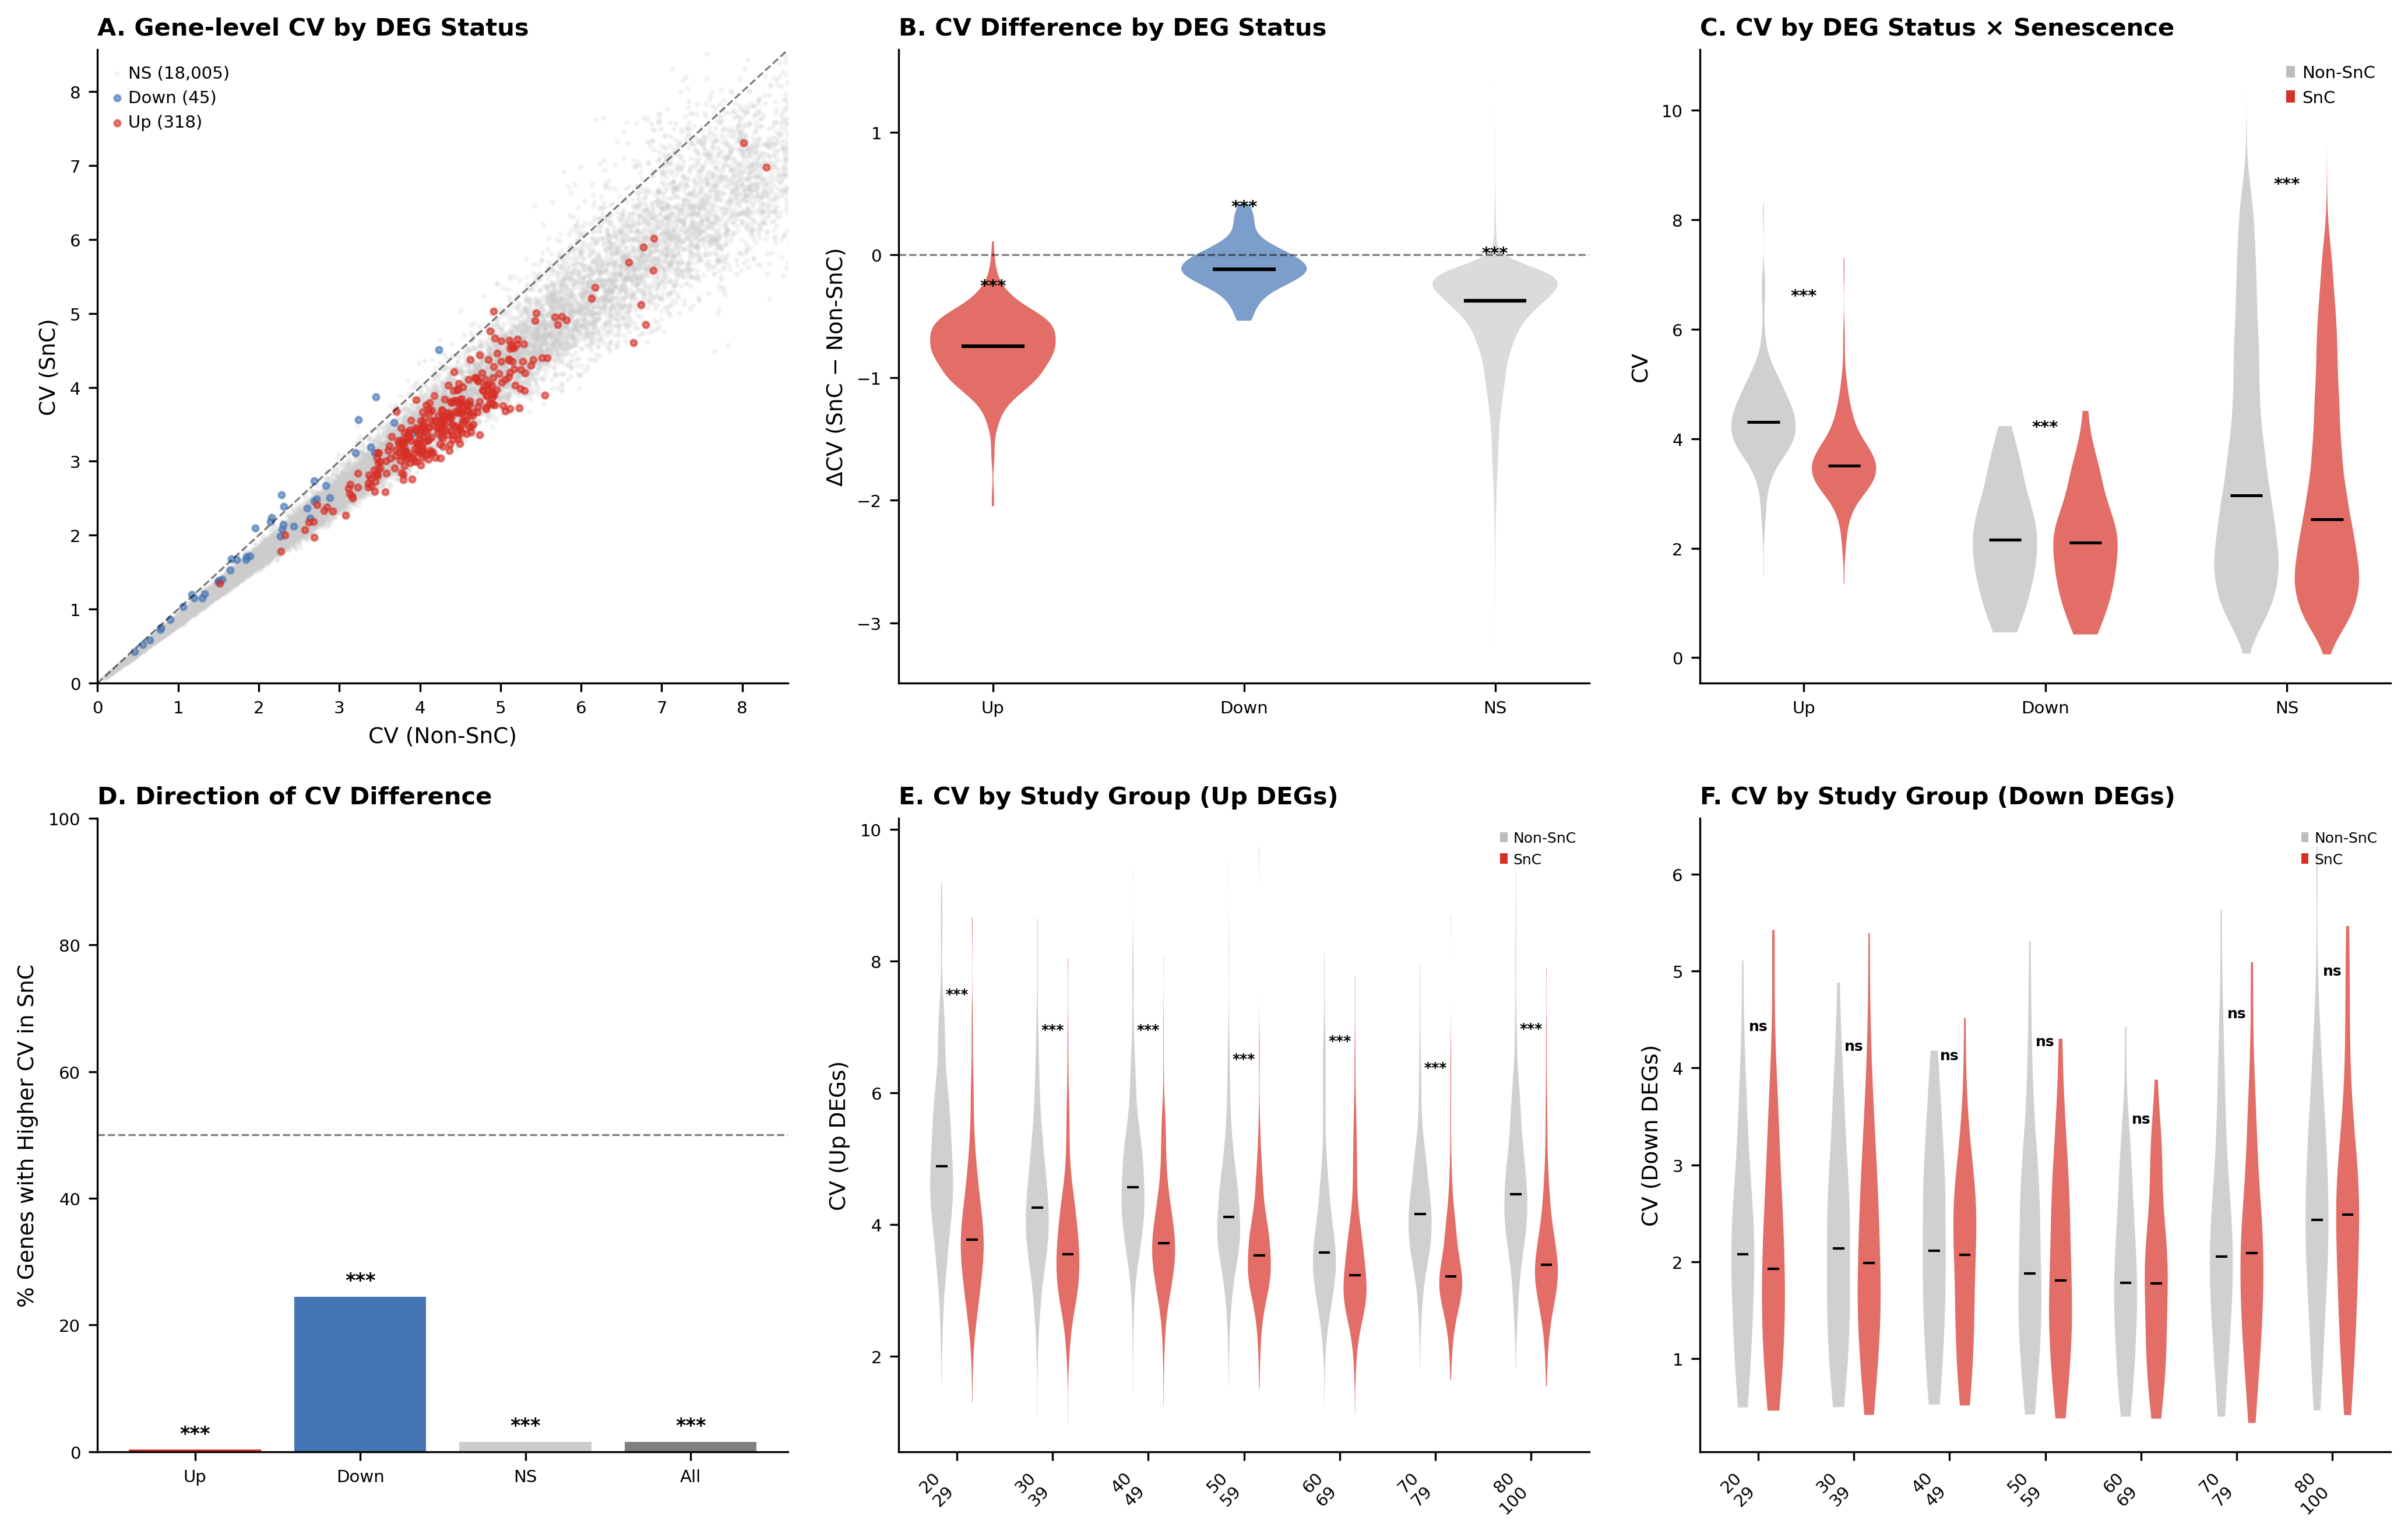

Saved DEG-stratified CV figure (6 panels + stats)


In [13]:
# ════════════════════════════════════════════════════════════════════════════════
# CV VISUALIZATION: STRATIFIED + PER STUDY GROUP
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("CV VISUALIZATION (DEG-STRATIFIED)")
print("=" * 60)

from scipy.stats import wilcoxon, mannwhitneyu
from matplotlib.patches import Patch

DEG_COLORS = {'Up': '#D73027', 'Down': '#4575B4', 'NS': '#CCCCCC', 'All': '#808080'}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# ── Panel A: Scatter ──
ax = axes[0, 0]
ax.grid(False)

for status, color in [('NS', '#CCCCCC'), ('Down', '#4575B4'), ('Up', '#D73027')]:
    sub = cv_data[cv_data['DEG_status'] == status]
    alpha = 0.15 if status == 'NS' else 0.6
    size = 2 if status == 'NS' else 6
    ax.scatter(sub['cv_NonSnC'], sub['cv_SnC'], s=size, c=color, alpha=alpha,
               label=f'{status} ({len(sub):,})', rasterized=True)

lim_max = max(cv_data['cv_SnC'].quantile(0.99), cv_data['cv_NonSnC'].quantile(0.99))
ax.plot([0, lim_max], [0, lim_max], 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('CV (Non-SnC)', fontsize=9); ax.set_ylabel('CV (SnC)', fontsize=9)
ax.set_title('A. Gene-level CV by DEG Status', fontsize=10, fontweight='bold', loc='left')
ax.legend(fontsize=7, frameon=False, loc='upper left')
ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=7)

# ── Panel B: ΔCV violin by DEG status + stats ──
ax = axes[0, 1]
ax.grid(False)

statuses_b = ['Up', 'Down', 'NS']
vp_data_b = [cv_data[cv_data['DEG_status'] == s]['cv_diff'].values for s in statuses_b]

parts_b = ax.violinplot(vp_data_b, positions=[0, 1, 2], showextrema=False, showmedians=True)
for i, (body, status) in enumerate(zip(parts_b['bodies'], statuses_b)):
    body.set_facecolor(DEG_COLORS[status]); body.set_alpha(0.7)
parts_b['cmedians'].set_color('black'); parts_b['cmedians'].set_linewidth(1.5)

ax.axhline(0, color='k', linestyle='--', lw=0.8, alpha=0.5)

# Stats: test if ΔCV != 0 per category
for i, status in enumerate(statuses_b):
    vals = cv_data[cv_data['DEG_status'] == status]['cv_diff'].values
    if len(vals) > 10:
        _, p = wilcoxon(vals)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        y_top = np.percentile(vals, 97)
        ax.text(i, y_top * 1.05, sig, ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['Up', 'Down', 'NS'], fontsize=8)
ax.set_ylabel('ΔCV (SnC − Non-SnC)', fontsize=9)
ax.set_title('B. CV Difference by DEG Status', fontsize=10, fontweight='bold', loc='left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=7)

# ── Panel C: Violin CV by DEG status × senescence + stats ──
ax = axes[0, 2]
ax.grid(False)

positions_c = []
vp_data_c = []
vp_colors_c = []

for i, status in enumerate(['Up', 'Down', 'NS']):
    sub = cv_data[cv_data['DEG_status'] == status]
    for j, (sen, col) in enumerate([('Non-SnC', 'cv_NonSnC'), ('SnC', 'cv_SnC')]):
        vals = sub[col].values
        if len(vals) > 0:
            positions_c.append(i * 3 + j * 1.0)
            vp_data_c.append(vals)
            vp_colors_c.append(SNC_COLORS[sen])

parts_c = ax.violinplot(vp_data_c, positions=positions_c, showextrema=False, showmedians=True, widths=0.8)
for body, color in zip(parts_c['bodies'], vp_colors_c):
    body.set_facecolor(color); body.set_alpha(0.7)
parts_c['cmedians'].set_color('black'); parts_c['cmedians'].set_linewidth(1.2)

# Stats per DEG category (paired by gene)
for i, status in enumerate(['Up', 'Down', 'NS']):
    sub = cv_data[cv_data['DEG_status'] == status]
    if len(sub) > 10:
        _, p = wilcoxon(sub['cv_SnC'], sub['cv_NonSnC'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        y_top = max(sub['cv_SnC'].quantile(0.97), sub['cv_NonSnC'].quantile(0.97))
        ax.text(i * 3 + 0.5, y_top * 1.05, sig, ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks([i * 3 + 0.5 for i in range(3)])
ax.set_xticklabels(['Up', 'Down', 'NS'], fontsize=8)
ax.set_ylabel('CV', fontsize=9)
ax.set_title('C. CV by DEG Status × Senescence', fontsize=10, fontweight='bold', loc='left')
ax.legend(handles=[Patch(facecolor=SNC_COLORS['Non-SnC'], label='Non-SnC'),
                   Patch(facecolor=SNC_COLORS['SnC'], label='SnC')],
          fontsize=7, frameon=False, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=7)

# ── Panel D: % genes with higher CV in SnC ──
ax = axes[1, 0]
ax.grid(False)

bar_data = df_cv_stats[df_cv_stats['DEG_status'].isin(['Up', 'Down', 'NS', 'All'])].copy()
bar_colors = [DEG_COLORS.get(s, '#808080') for s in bar_data['DEG_status']]

bars = ax.bar(range(len(bar_data)), bar_data['pct_higher_SnC'], color=bar_colors, edgecolor='none')
ax.axhline(50, color='k', linestyle='--', lw=0.8, alpha=0.5)

for i, (_, row) in enumerate(bar_data.iterrows()):
    sig = '***' if row['wilcoxon_p'] < 0.001 else '**' if row['wilcoxon_p'] < 0.01 else '*' if row['wilcoxon_p'] < 0.05 else 'ns'
    ax.text(i, row['pct_higher_SnC'] + 1, sig, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(range(len(bar_data)))
ax.set_xticklabels(bar_data['DEG_status'], fontsize=8)
ax.set_ylabel('% Genes with Higher CV in SnC', fontsize=9)
ax.set_ylim(0, 100)
ax.set_title('D. Direction of CV Difference', fontsize=10, fontweight='bold', loc='left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=7)

# ── Panel E: Violin CV by Study Group (Up DEGs) + stats ──
ax = axes[1, 1]
ax.grid(False)

study_groups = [g for g in GROUP_ORDER if g in adata_balanced.obs[STUDY_GROUP_COL].values]
up_genes = cv_data[cv_data['DEG_status'] == 'Up']['gene'].values
up_idx = [list(adata_balanced.var_names).index(g) for g in up_genes if g in adata_balanced.var_names]

sg_cv_up = []
for sg in study_groups:
    sg_mask = adata_balanced.obs[STUDY_GROUP_COL] == sg
    for is_snc in [True, False]:
        cell_mask = sg_mask & (adata_balanced.obs['is_senescent'] == is_snc)
        if cell_mask.sum() < 20:
            continue
        X_sub = adata_balanced.X[cell_mask.values][:, up_idx]
        if issparse(X_sub): X_sub = X_sub.toarray()
        means = X_sub.mean(axis=0)
        stds = X_sub.std(axis=0)
        valid = means > MIN_MEAN
        if valid.sum() < 5: continue
        cvs = stds[valid] / means[valid]
        for cv_val in cvs:
            sg_cv_up.append({'Study_Group': sg, 'Senescence': 'SnC' if is_snc else 'Non-SnC', 'CV': float(cv_val)})

sg_cv_up_df = pd.DataFrame(sg_cv_up)

positions_e = []
vp_data_e = []
vp_colors_e = []

for i, sg in enumerate(study_groups):
    for j, sen in enumerate(['Non-SnC', 'SnC']):
        vals = sg_cv_up_df[(sg_cv_up_df['Study_Group'] == sg) & (sg_cv_up_df['Senescence'] == sen)]['CV'].values
        if len(vals) > 5:
            positions_e.append(i * 2.5 + j * 0.8)
            vp_data_e.append(vals)
            vp_colors_e.append(SNC_COLORS[sen])

if vp_data_e:
    parts_e = ax.violinplot(vp_data_e, positions=positions_e, showextrema=False, showmedians=True, widths=0.6)
    for body, color in zip(parts_e['bodies'], vp_colors_e):
        body.set_facecolor(color); body.set_alpha(0.7)
    parts_e['cmedians'].set_color('black'); parts_e['cmedians'].set_linewidth(1.0)

# Stats per study group
for i, sg in enumerate(study_groups):
    snc_vals = sg_cv_up_df[(sg_cv_up_df['Study_Group'] == sg) & (sg_cv_up_df['Senescence'] == 'SnC')]['CV'].values
    nonsnc_vals = sg_cv_up_df[(sg_cv_up_df['Study_Group'] == sg) & (sg_cv_up_df['Senescence'] == 'Non-SnC')]['CV'].values
    if len(snc_vals) > 5 and len(nonsnc_vals) > 5:
        _, p = mannwhitneyu(snc_vals, nonsnc_vals, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        y_top = max(np.percentile(snc_vals, 95), np.percentile(nonsnc_vals, 95))
        ax.text(i * 2.5 + 0.4, y_top * 1.05, sig, ha='center', va='bottom', fontsize=6, fontweight='bold')

ax.set_xticks([i * 2.5 + 0.4 for i in range(len(study_groups))])
ax.set_xticklabels([g.replace('_', '\n').replace('Age\n', '') for g in study_groups],
                   fontsize=6, rotation=45, ha='right')
ax.set_ylabel('CV (Up DEGs)', fontsize=9)
ax.set_title('E. CV by Study Group (Up DEGs)', fontsize=10, fontweight='bold', loc='left')
ax.legend(handles=[Patch(facecolor=SNC_COLORS['Non-SnC'], label='Non-SnC'),
                   Patch(facecolor=SNC_COLORS['SnC'], label='SnC')],
          fontsize=6, frameon=False, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=7)

# ── Panel F: Violin CV by Study Group (Down DEGs) + stats ──
ax = axes[1, 2]
ax.grid(False)

down_genes = cv_data[cv_data['DEG_status'] == 'Down']['gene'].values
down_idx = [list(adata_balanced.var_names).index(g) for g in down_genes if g in adata_balanced.var_names]

sg_cv_down = []
for sg in study_groups:
    sg_mask = adata_balanced.obs[STUDY_GROUP_COL] == sg
    for is_snc in [True, False]:
        cell_mask = sg_mask & (adata_balanced.obs['is_senescent'] == is_snc)
        if cell_mask.sum() < 20:
            continue
        X_sub = adata_balanced.X[cell_mask.values][:, down_idx]
        if issparse(X_sub): X_sub = X_sub.toarray()
        means = X_sub.mean(axis=0)
        stds = X_sub.std(axis=0)
        valid = means > MIN_MEAN
        if valid.sum() < 5: continue
        cvs = stds[valid] / means[valid]
        for cv_val in cvs:
            sg_cv_down.append({'Study_Group': sg, 'Senescence': 'SnC' if is_snc else 'Non-SnC', 'CV': float(cv_val)})

sg_cv_down_df = pd.DataFrame(sg_cv_down)

positions_f = []
vp_data_f = []
vp_colors_f = []

for i, sg in enumerate(study_groups):
    for j, sen in enumerate(['Non-SnC', 'SnC']):
        vals = sg_cv_down_df[(sg_cv_down_df['Study_Group'] == sg) & (sg_cv_down_df['Senescence'] == sen)]['CV'].values
        if len(vals) > 5:
            positions_f.append(i * 2.5 + j * 0.8)
            vp_data_f.append(vals)
            vp_colors_f.append(SNC_COLORS[sen])

if vp_data_f:
    parts_f = ax.violinplot(vp_data_f, positions=positions_f, showextrema=False, showmedians=True, widths=0.6)
    for body, color in zip(parts_f['bodies'], vp_colors_f):
        body.set_facecolor(color); body.set_alpha(0.7)
    parts_f['cmedians'].set_color('black'); parts_f['cmedians'].set_linewidth(1.0)

# Stats per study group
for i, sg in enumerate(study_groups):
    snc_vals = sg_cv_down_df[(sg_cv_down_df['Study_Group'] == sg) & (sg_cv_down_df['Senescence'] == 'SnC')]['CV'].values
    nonsnc_vals = sg_cv_down_df[(sg_cv_down_df['Study_Group'] == sg) & (sg_cv_down_df['Senescence'] == 'Non-SnC')]['CV'].values
    if len(snc_vals) > 5 and len(nonsnc_vals) > 5:
        _, p = mannwhitneyu(snc_vals, nonsnc_vals, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        y_top = max(np.percentile(snc_vals, 95), np.percentile(nonsnc_vals, 95))
        ax.text(i * 2.5 + 0.4, y_top * 1.05, sig, ha='center', va='bottom', fontsize=6, fontweight='bold')

ax.set_xticks([i * 2.5 + 0.4 for i in range(len(study_groups))])
ax.set_xticklabels([g.replace('_', '\n').replace('Age\n', '') for g in study_groups],
                   fontsize=6, rotation=45, ha='right')
ax.set_ylabel('CV (Down DEGs)', fontsize=9)
ax.set_title('F. CV by Study Group (Down DEGs)', fontsize=10, fontweight='bold', loc='left')
ax.legend(handles=[Patch(facecolor=SNC_COLORS['Non-SnC'], label='Non-SnC'),
                   Patch(facecolor=SNC_COLORS['SnC'], label='SnC')],
          fontsize=6, frameon=False, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_cv_deg_stratified.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_cv_deg_stratified.svg', dpi=300, bbox_inches='tight')
plt.show()
print("Saved DEG-stratified CV figure (6 panels + stats)")

---

## Donor-Level CV (DEG-Stratified)

In [14]:
# ════════════════════════════════════════════════════════════════════════════════
# DONOR-LEVEL CV: DEG-STRATIFIED
# ════════════════════════════════════════════════════════════════════════════════

from scipy.stats import wilcoxon

print("=" * 60)
print("DONOR-LEVEL CV (DEG-STRATIFIED)")
print("=" * 60)

# Get gene indices per DEG category
deg_gene_sets = {}
for status in ['Up', 'Down', 'NS']:
    genes = cv_data[cv_data['DEG_status'] == status]['gene'].values
    gene_idx = [list(adata_balanced.var_names).index(g) for g in genes if g in adata_balanced.var_names]
    deg_gene_sets[status] = gene_idx
    print(f"  {status}: {len(gene_idx)} genes in expression matrix")

donor_cv_deg = []

for donor in adata_balanced.obs[SAMPLE_COL].unique():
    donor_mask = adata_balanced.obs[SAMPLE_COL] == donor
    study_group = adata_balanced.obs.loc[donor_mask, STUDY_GROUP_COL].iloc[0]

    for is_snc in [True, False]:
        cell_mask = donor_mask & (adata_balanced.obs['is_senescent'] == is_snc)
        n_cells = cell_mask.sum()

        if n_cells < MIN_CELLS_PER_GROUP:
            continue

        X_sub = adata_balanced.X[cell_mask.values]
        if issparse(X_sub):
            X_sub = X_sub.toarray()

        for status, gene_idx in deg_gene_sets.items():
            if len(gene_idx) < 10:
                continue

            X_genes = X_sub[:, gene_idx]
            means = X_genes.mean(axis=0)
            stds = X_genes.std(axis=0)
            valid = means > MIN_MEAN
            if valid.sum() < 5:
                continue

            cvs = stds[valid] / means[valid]

            donor_cv_deg.append({
                'donor': donor,
                'Study_Group': study_group,
                'Senescence': 'SnC' if is_snc else 'Non-SnC',
                'DEG_status': status,
                'n_cells': n_cells,
                'median_cv': float(np.median(cvs)),
                'mean_cv': float(cvs.mean()),
                'n_genes': int(valid.sum()),
            })

donor_cv_deg = pd.DataFrame(donor_cv_deg)
print(f"\n  Total observations: {len(donor_cv_deg)}")

# Paired tests per DEG category
print(f"\n  {'DEG Status':<10} {'n_paired':>8} {'SnC CV':>10} {'NonSnC CV':>10} {'p':>10} {'Direction':<15}")
print(f"  {'─'*65}")

donor_cv_paired_stats = []

for status in ['Up', 'Down', 'NS']:
    sub = donor_cv_deg[donor_cv_deg['DEG_status'] == status]
    donors_s = set(sub[sub['Senescence'] == 'SnC']['donor'])
    donors_n = set(sub[sub['Senescence'] == 'Non-SnC']['donor'])
    paired = sorted(donors_s & donors_n)

    if len(paired) < 5:
        print(f"  {status:<10} {'<5 paired':>8}")
        continue

    pivot = sub[sub['donor'].isin(paired)].pivot(index='donor', columns='Senescence', values='median_cv')
    stat, pval = wilcoxon(pivot['SnC'], pivot['Non-SnC'])
    med_s = pivot['SnC'].median()
    med_n = pivot['Non-SnC'].median()
    direction = "SnC > Non-SnC" if med_s > med_n else "Non-SnC > SnC"

    donor_cv_paired_stats.append({
        'DEG_status': status, 'n_paired': len(paired),
        'median_cv_SnC': med_s, 'median_cv_NonSnC': med_n,
        'wilcoxon_p': pval, 'direction': direction,
    })

    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"  {status:<10} {len(paired):>8} {med_s:>10.4f} {med_n:>10.4f} {pval:>10.2e} {direction:<15} {sig}")

DONOR-LEVEL CV (DEG-STRATIFIED)
  Up: 318 genes in expression matrix
  Down: 45 genes in expression matrix
  NS: 18005 genes in expression matrix

  Total observations: 300

  DEG Status n_paired     SnC CV  NonSnC CV          p Direction      
  ─────────────────────────────────────────────────────────────────
  Up               50     3.3406     4.0715   1.11e-09 Non-SnC > SnC   ***
  Down             50     1.9459     2.0543   1.11e-03 Non-SnC > SnC   **
  NS               50     2.2693     2.5165   3.55e-15 Non-SnC > SnC   ***


DONOR-LEVEL CV FIGURE


/tmp/ipykernel_1376559/1608602475.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  donor_cmap = cm.get_cmap('tab20', len(paired))
/tmp/ipykernel_1376559/1608602475.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  donor_cmap = cm.get_cmap('tab20', len(paired))
/tmp/ipykernel_1376559/1608602475.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  donor_cmap = cm.get_cmap('tab20', len(paired))


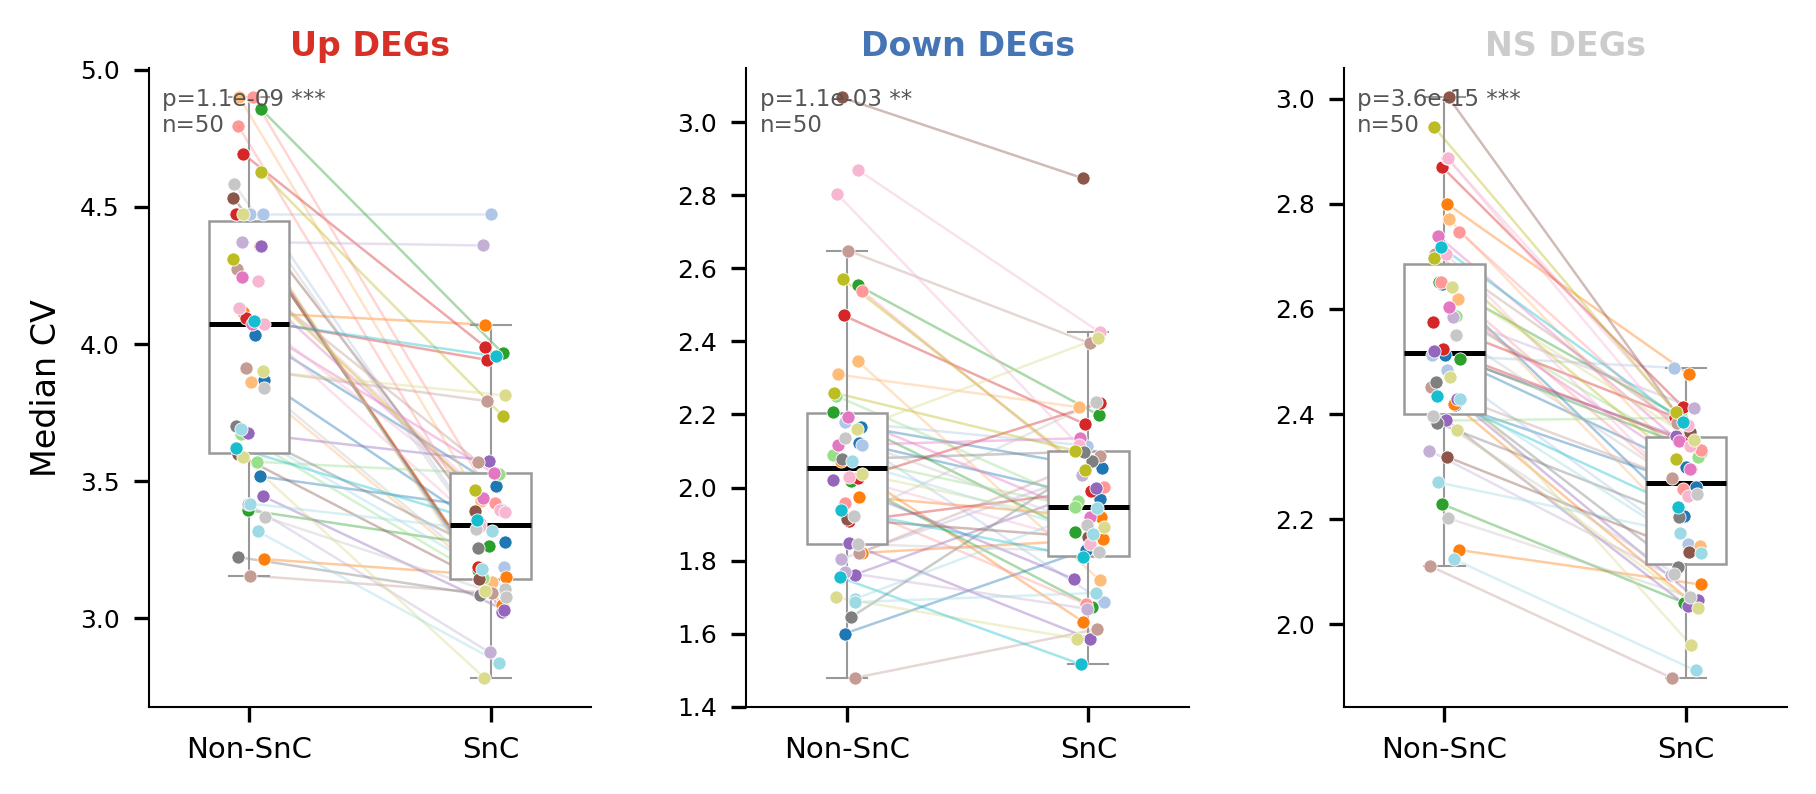

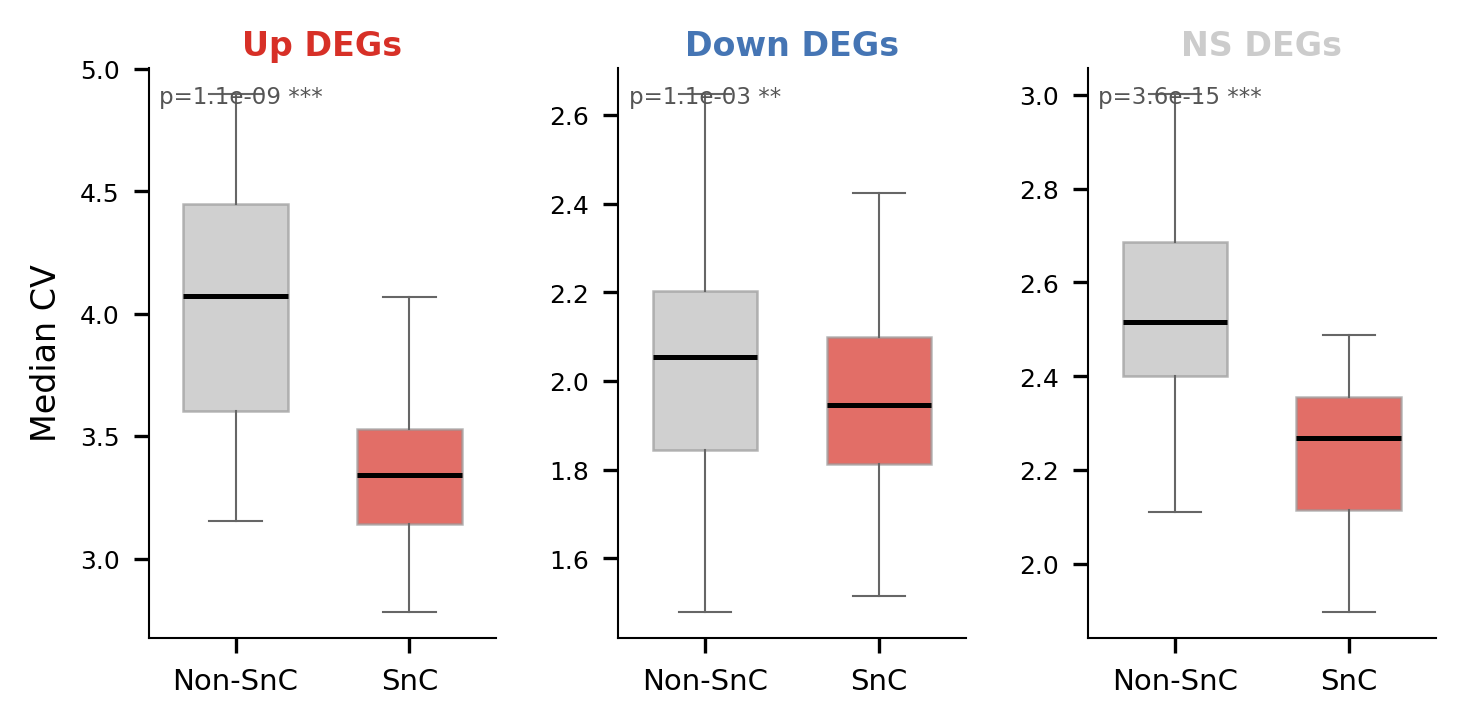

Saved clean donor-level CV figure


In [15]:
# ════════════════════════════════════════════════════════════════════════════════
# DONOR-LEVEL CV FIGURE (DEG-STRATIFIED)
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("DONOR-LEVEL CV FIGURE")
print("=" * 60)

import matplotlib.cm as cm

statuses = ['Up', 'Down', 'NS']

fig, axes = plt.subplots(1, 3, figsize=(7, 2.8))

for ax, status in zip(axes, statuses):
    ax.grid(False)
    sub = donor_cv_deg[donor_cv_deg['DEG_status'] == status]

    donors_s = set(sub[sub['Senescence'] == 'SnC']['donor'])
    donors_n = set(sub[sub['Senescence'] == 'Non-SnC']['donor'])
    paired = sorted(donors_s & donors_n)

    if len(paired) < 5:
        ax.text(0.5, 0.5, f'{status}\nn < 5', ha='center', va='center',
                transform=ax.transAxes, fontsize=8, color='gray')
        for spine in ax.spines.values(): spine.set_visible(False)
        ax.set_xticks([]); ax.set_yticks([])
        continue

    pivot = sub[sub['donor'].isin(paired)].pivot(index='donor', columns='Senescence', values='median_cv')

    # Unique color per donor
    donor_cmap = cm.get_cmap('tab20', len(paired))
    donor_colors = {d: donor_cmap(i) for i, d in enumerate(paired)}

    # Slim boxplots
    bp = ax.boxplot([pivot['Non-SnC'], pivot['SnC']],
                    positions=[0, 0.6], widths=0.2, showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor='white', edgecolor='#999', linewidth=0.6),
                    medianprops=dict(color='k', linewidth=1.2),
                    whiskerprops=dict(color='#999', linewidth=0.5),
                    capprops=dict(color='#999', linewidth=0.5))

    # Paired lines + jittered dots, colored per donor
    for donor in pivot.index:
        c = donor_colors[donor]
        jx = np.random.uniform(-0.04, 0.04)
        ax.plot([0 + jx, 0.6 + jx],
                [pivot.loc[donor, 'Non-SnC'], pivot.loc[donor, 'SnC']],
                c=c, alpha=0.4, lw=0.6, zorder=1)
        ax.scatter(0 + jx, pivot.loc[donor, 'Non-SnC'],
                   c=[c], s=10, edgecolor='white', linewidth=0.2, zorder=3)
        ax.scatter(0.6 + jx, pivot.loc[donor, 'SnC'],
                   c=[c], s=10, edgecolor='white', linewidth=0.2, zorder=3)

    # Stats
    stat_row = [s for s in donor_cv_paired_stats if s['DEG_status'] == status]
    if stat_row:
        pval = stat_row[0]['wilcoxon_p']
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        ax.text(0.03, 0.97, f'p={pval:.1e} {sig}\nn={len(paired)}',
                transform=ax.transAxes, fontsize=5.5, ha='left', va='top', color='#555')

    ax.set_xlim(-0.25, 0.85)
    ax.set_xticks([0, 0.6])
    ax.set_xticklabels(['Non-SnC', 'SnC'], fontsize=7)
    ax.set_title(f'{status} DEGs', fontsize=8, fontweight='bold',
                 color=DEG_COLORS.get(status, '#333'), pad=3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5); ax.spines['left'].set_linewidth(0.5)
    ax.tick_params(axis='y', labelsize=6)

    if ax == axes[0]:
        ax.set_ylabel('Median CV', fontsize=8)

plt.subplots_adjust(wspace=0.35)
plt.savefig(FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_cv_donor_deg.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_cv_donor_deg.svg', dpi=300, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════════
# DONOR-LEVEL CV FIGURE — CLEAN (NO DOTS)
# ════════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(5.5, 2.5))

for ax, status in zip(axes, statuses):
    ax.grid(False)
    sub = donor_cv_deg[donor_cv_deg['DEG_status'] == status]

    donors_s = set(sub[sub['Senescence'] == 'SnC']['donor'])
    donors_n = set(sub[sub['Senescence'] == 'Non-SnC']['donor'])
    paired = sorted(donors_s & donors_n)

    if len(paired) < 5:
        ax.text(0.5, 0.5, f'{status}\nn < 5', ha='center', va='center',
                transform=ax.transAxes, fontsize=8, color='gray')
        for spine in ax.spines.values(): spine.set_visible(False)
        ax.set_xticks([]); ax.set_yticks([])
        continue

    pivot = sub[sub['donor'].isin(paired)].pivot(index='donor', columns='Senescence', values='median_cv')

    bp = ax.boxplot([pivot['Non-SnC'], pivot['SnC']],
                    positions=[0, 0.5], widths=0.3, showfliers=False, patch_artist=True,
                    boxprops=dict(linewidth=0.6),
                    medianprops=dict(color='k', linewidth=1.2),
                    whiskerprops=dict(color='#666', linewidth=0.5),
                    capprops=dict(color='#666', linewidth=0.5))

    bp['boxes'][0].set_facecolor(SNC_COLORS['Non-SnC']); bp['boxes'][0].set_alpha(0.7); bp['boxes'][0].set_edgecolor('#999')
    bp['boxes'][1].set_facecolor(SNC_COLORS['SnC']); bp['boxes'][1].set_alpha(0.7); bp['boxes'][1].set_edgecolor('#999')

    # Stats
    stat_row = [s for s in donor_cv_paired_stats if s['DEG_status'] == status]
    if stat_row:
        pval = stat_row[0]['wilcoxon_p']
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        ax.text(0.03, 0.97, f'p={pval:.1e} {sig}',
                transform=ax.transAxes, fontsize=5.5, ha='left', va='top', color='#555')

    ax.set_xlim(-0.25, 0.75)
    ax.set_xticks([0, 0.5])
    ax.set_xticklabels(['Non-SnC', 'SnC'], fontsize=7)
    ax.set_title(f'{status} DEGs', fontsize=8, fontweight='bold',
                 color=DEG_COLORS.get(status, '#333'), pad=3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5); ax.spines['left'].set_linewidth(0.5)
    ax.tick_params(axis='y', labelsize=6)

    if ax == axes[0]:
        ax.set_ylabel('Median CV', fontsize=8)

plt.subplots_adjust(wspace=0.35)
plt.savefig(FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_cv_donor_deg_clean.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_cv_donor_deg_clean.svg', dpi=300, bbox_inches='tight')
plt.show()
print("Saved clean donor-level CV figure")

---

## Variance Partitioning Analysis

**Question**: What factors explain variance in gene expression, and how does senescence compare to donor, age, and sex effects?

**Method**: Linear mixed models via `variancePartition` (R) decompose variance into Donor, Senescence, Study_Group, Sex, and Residual components.

**Note**: This analysis uses R for the `variancePartition` package — run the generated R script after preparing data in Python.

---

In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# MODULE 08C: VARIANCE PARTITIONING ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════
# Question: What factors explain variance in gene expression?
# Method: variancePartition on pseudobulk (donor × senescence)
# ════════════════════════════════════════════════════════════════════════════════

# ────────────────────────────────────────────────────────────────────────────────
# 08C-1: LIBRARIES
# ────────────────────────────────────────────────────────────────────────────────

suppressPackageStartupMessages({
  library(variancePartition)
  library(edgeR)
  library(ggplot2)
  library(dplyr)
  library(Seurat)
  library(qs)
})

cat("✓ Libraries loaded\n")

Warning message:
“package ‘variancePartition’ was built under R version 4.3.2”
Warning message:
“package ‘limma’ was built under R version 4.3.3”
Warning message:
“package ‘BiocParallel’ was built under R version 4.3.3”
Warning message:
“package ‘edgeR’ was built under R version 4.3.3”
Warning message:
“package ‘dplyr’ was built under R version 4.3.3”
Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Warning message:
“package ‘sp’ was built under R version 4.3.3”
Warning message:
“package ‘qs’ was built under R version 4.3.3”


✓ Libraries loaded


In [2]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-2: CONFIGURATION
# ────────────────────────────────────────────────────────────────────────────────

DATASET <- "psychad_aging"
CELL_TYPE <- "OPC"

STUDY_CONFIG <- list(
  psychad_aging = list(
    type = "aging",
    cell_type_col = "subclass",
    sample_col = "Sample",
    senescence_col = "senescence_label",
    covariates = list(
      Donor = "Sample",
      Senescence = "senescence_label",
      Study_Group = "Study_Group",
      Sex = "Sex",
      Cohort = "Cohort",
      Log_Library_Depth = "Log_Library_Depth" 
    ),
    group_order = c("Age_20_29", "Age_30_39", "Age_40_49", "Age_50_59",
                    "Age_60_69", "Age_70_79", "Age_80_100")
  ),
  psychad_ad = list(
    type = "disease",
    cell_type_col = "subclass",
    sample_col = "Sample",
    senescence_col = "senescence_label",
    covariates = list(
      Donor = "Sample",
      Senescence = "senescence_label",
      Study_Group = "Study_Group",
      Sex = "Sex",
      Cohort = "Cohort",
      Log_Library_Depth = "Log_Library_Depth"  
    ),
    group_order = c("Control", "MCI", "AD")
  ),
  psychencode = list(
    type = "aging",
    cell_type_col = "cell_type",
    sample_col = "sample_id",
    senescence_col = "senescence_label",
    covariates = list(
      Donor = "sample_id",
      Senescence = "senescence_label",
      Study_Group = "Study_Group",
      Sex = "Biological_Sex",
      Cohort = "Cohort",
      Log_Library_Depth = "Log_Library_Depth" 
    ),
    group_order = c("Age_20_29", "Age_30_39", "Age_40_49", "Age_50_59",
                    "Age_60_69", "Age_70_79", "Age_80_100")
  )
)

# Extract config
config <- STUDY_CONFIG[[DATASET]]
CELL_TYPE_COL <- config$cell_type_col
SAMPLE_COL <- config$sample_col
SENESCENCE_COL <- config$senescence_col
COVARIATES <- config$covariates

# Paths
BASE_DIR <- "/fs/scratch/PAS2598/senescence_analysis"
SC_FILE <- file.path(BASE_DIR, "data", "04_subsetting", DATASET, paste0(DATASET, "_subclustered.qs"))
RESULTS_DIR <- file.path(BASE_DIR, "results", "08_variability", DATASET, tolower(CELL_TYPE))
FIGURES_DIR <- file.path(BASE_DIR, "figures", "08_variability", DATASET, tolower(CELL_TYPE))

dir.create(RESULTS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIGURES_DIR, recursive = TRUE, showWarnings = FALSE)

# Colors
VP_COLORS <- c(
  "Donor" = "#4E79A7",
  "Senescence" = "#D73027",
  "Study_Group" = "#59A14F",
  "Sex" = "#F28E2B",
  "Cohort" = "#B07AA1",
  "Log_Library_Depth" = "#76B7B2",
  "Residuals" = "#BDBDBD"
)  

cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("Dataset:", DATASET, "\n")
cat("Cell type:", CELL_TYPE, "\n")
cat("Covariates:", paste(names(COVARIATES), collapse = ", "), "\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")

════════════════════════════════════════════════════════════════════════════════
Dataset: psychad_aging 
Cell type: OPC 
Covariates: Donor, Senescence, Study_Group, Sex, Cohort, Log_Library_Depth 
════════════════════════════════════════════════════════════════════════════════


In [3]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-3: LOAD DATA
# ────────────────────────────────────────────────────────────────────────────────

cat("\nLoading data...\n")

seurat_all <- qread(SC_FILE)
cat("  Total cells:", ncol(seurat_all), "\n")

seurat <- subset(seurat_all, subset = !!sym(CELL_TYPE_COL) == CELL_TYPE)
cat(" ", CELL_TYPE, "cells:", ncol(seurat), "\n")

cat("\nSenescence distribution:\n")
print(table(seurat@meta.data[[SENESCENCE_COL]]))

rm(seurat_all)
gc()

cat("\n✓ Data loaded\n")


Loading data...
  Total cells: 122192 
  OPC cells: 36059 

Senescence distribution:

Non-SnC     SnC 
  33333    2726 


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4541446,242.6,7922075,423.1,7922075,423.1
Vcells,1623638952,12387.4,8118004347,61935.5,8307935455,63384.6



✓ Data loaded


In [4]:
seurat

An object of class Seurat 
34890 features across 36059 samples within 1 assay 
Active assay: RNA (34890 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [5]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-4: CREATE PSEUDOBULK
# ────────────────────────────────────────────────────────────────────────────────

cat("\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("Creating pseudobulk...\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")

counts <- GetAssayData(seurat, layer = "counts")

seurat$donor_snc <- paste0(seurat@meta.data[[SAMPLE_COL]], "-", 
                           seurat@meta.data[[SENESCENCE_COL]])

donor_snc_ids <- unique(seurat$donor_snc)
cat("  Aggregating", length(donor_snc_ids), "samples...\n")

pseudobulk <- sapply(donor_snc_ids, function(id) {
  cells <- which(seurat$donor_snc == id)
  if (length(cells) > 1) {
    Matrix::rowSums(counts[, cells])
  } else {
    counts[, cells]
  }
})
colnames(pseudobulk) <- donor_snc_ids

cat("  Pseudobulk:", nrow(pseudobulk), "genes x", ncol(pseudobulk), "samples\n")


════════════════════════════════════════════════════════════════════════════════
Creating pseudobulk...
════════════════════════════════════════════════════════════════════════════════
  Aggregating 239 samples...
  Pseudobulk: 34890 genes x 239 samples


In [6]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-5: CREATE METADATA
# ────────────────────────────────────────────────────────────────────────────────
cat("\nCreating metadata...\n")

# Build summarise expressions dynamically (exclude Log_Library_Depth — computed from pseudobulk)
meta_covariates <- COVARIATES[names(COVARIATES) != "Log_Library_Depth"]

summarise_exprs <- lapply(names(meta_covariates), function(out_name) {
  src_col <- meta_covariates[[out_name]]
  rlang::expr(first(.data[[!!src_col]]))
})

names(summarise_exprs) <- names(meta_covariates)

summarise_exprs$n_cells <- rlang::expr(n())

meta <- seurat@meta.data %>%
  mutate(donor_snc = paste0(.data[[SAMPLE_COL]], "-", .data[[SENESCENCE_COL]])) %>%
  group_by(donor_snc) %>%
  summarise(!!!summarise_exprs, .groups = "drop") %>%
  as.data.frame()

rownames(meta) <- meta$donor_snc

cat("  Samples:", nrow(meta), "\n")

# Check NAs
na_check <- sapply(meta[, names(meta_covariates), drop = FALSE], function(x) sum(is.na(x)))
if (any(na_check > 0)) {
  cat("  ⚠ NAs found:", paste(names(na_check)[na_check > 0], na_check[na_check > 0], sep = "=", collapse = ", "), "\n")
} else {
  cat("  ✓ No missing values\n")
}


Creating metadata...
  Samples: 239 
  ✓ No missing values


In [7]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-6: FILTER AND NORMALIZE
# ────────────────────────────────────────────────────────────────────────────────
cat("\nFiltering and normalizing...\n")

common_samples <- intersect(colnames(pseudobulk), rownames(meta))

pseudobulk <- pseudobulk[, common_samples]

meta <- meta[common_samples, ]

cat("  Aligned samples:", length(common_samples), "\n")

# Add Log_Library_Depth (computed from pseudobulk, not from Seurat metadata)
meta$Log_Library_Depth <- log10(colSums(pseudobulk))

cat("  Log_Library_Depth range:", round(min(meta$Log_Library_Depth), 2), "-",
    round(max(meta$Log_Library_Depth), 2), "\n")

dge <- DGEList(counts = pseudobulk)

keep <- filterByExpr(dge, min.count = 10, min.total.count = 15)

dge <- dge[keep, ]

cat("  Genes after filtering:", nrow(dge), "\n")

dge <- calcNormFactors(dge, method = "TMM")

logCPM <- cpm(dge, log = TRUE, prior.count = 1)

cat("  Final:", nrow(logCPM), "genes x", ncol(logCPM), "samples\n")

# Verify alignment
stopifnot(all(colnames(logCPM) == rownames(meta)))

cat("  ✓ Alignment verified\n")


Filtering and normalizing...
  Aligned samples: 239 
  Log_Library_Depth range: 3.85 - 6.78 


Warning message in filterByExpr.DGEList(dge, min.count = 10, min.total.count = 15):
“All samples appear to belong to the same group.”


  Genes after filtering: 7893 
  Final: 7893 genes x 239 samples
  ✓ Alignment verified


In [8]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-7: RUN VARIANCE PARTITIONING
# ────────────────────────────────────────────────────────────────────────────────
cat("\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("Running variance partitioning...\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")

# Convert categorical covariates to factors (NOT Log_Library_Depth)
categorical_covs <- setdiff(names(COVARIATES), "Log_Library_Depth")
for (cov in categorical_covs) {
  meta[[cov]] <- as.factor(meta[[cov]])
}

# Ensure Log_Library_Depth is numeric
meta$Log_Library_Depth <- as.numeric(meta$Log_Library_Depth)

cat("\nFactor levels:\n")
for (cov in categorical_covs) {
  n_lev <- nlevels(meta[[cov]])
  if (n_lev <= 5) {
    cat("  ", cov, ": ", paste(levels(meta[[cov]]), collapse = ", "), "\n", sep = "")
  } else {
    cat("  ", cov, ": ", n_lev, " levels\n", sep = "")
  }
}
cat("  Log_Library_Depth: continuous (range ",
    round(min(meta$Log_Library_Depth), 2), " - ",
    round(max(meta$Log_Library_Depth), 2), ")\n", sep = "")

# Build formula: random effects for categorical, fixed for continuous
random_covs <- categorical_covs
fixed_covs <- c("Log_Library_Depth")

form_str <- paste0("~ ",
  paste0("(1|", random_covs, ")", collapse = " + "),
  " + ",
  paste0(fixed_covs, collapse = " + ")
)
form <- as.formula(form_str)
cat("\nFormula:", form_str, "\n")
cat("Genes:", nrow(logCPM), "\n")
cat("Samples:", ncol(logCPM), "\n")

cat("\nRunning... (this may take several minutes)\n")
varPart <- fitExtractVarPartModel(logCPM, form, meta)
cat("\n✓ Variance partitioning complete\n")


════════════════════════════════════════════════════════════════════════════════
Running variance partitioning...
════════════════════════════════════════════════════════════════════════════════

Factor levels:
  Donor: 124 levels
  Senescence: Non-SnC, SnC
  Study_Group: 7 levels
  Sex: Female, Male
  Cohort: HBCC, Mt Sinai Brain Bank
  Log_Library_Depth: continuous (range 3.85 - 6.78)

Formula: ~ (1|Donor) + (1|Senescence) + (1|Study_Group) + (1|Sex) + (1|Cohort) + Log_Library_Depth 
Genes: 7893 
Samples: 239 

Running... (this may take several minutes)

✓ Variance partitioning complete


In [9]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-8: RESULTS
# ────────────────────────────────────────────────────────────────────────────────

cat("\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("Results\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")

varPart_summary <- data.frame(
  Factor = colnames(varPart),
  Mean_pct = round(colMeans(varPart) * 100, 2),
  Median_pct = round(apply(varPart, 2, median) * 100, 2),
  SD_pct = round(apply(varPart, 2, sd) * 100, 2)
)
varPart_summary <- varPart_summary[order(-varPart_summary$Mean_pct), ]

print(varPart_summary, row.names = FALSE)


════════════════════════════════════════════════════════════════════════════════
Results
════════════════════════════════════════════════════════════════════════════════
            Factor Mean_pct Median_pct SD_pct
         Residuals    63.17      63.80  16.80
 Log_Library_Depth    21.96      22.54   9.90
             Donor     9.05       4.55  12.61
        Senescence     4.02       3.52   3.76
       Study_Group     1.12       0.23   2.06
            Cohort     0.36       0.00   0.94
               Sex     0.32       0.00   1.25


In [10]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-9: VISUALIZATION
# ────────────────────────────────────────────────────────────────────────────────

cat("\nCreating figures...\n")

# Violin plot
pdf(file.path(FIGURES_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_varpart_violin.pdf")),
    width = 6, height = 4)
plotVarPart(varPart, col = VP_COLORS[colnames(varPart)])
dev.off()
cat("  ✓ varpart_violin.svg\n")

# Bar plot
p <- ggplot(varPart_summary, aes(x = reorder(Factor, -Mean_pct), y = Mean_pct, fill = Factor)) +
  geom_bar(stat = "identity", width = 0.7) +
  geom_errorbar(aes(ymin = Mean_pct - SD_pct, ymax = Mean_pct + SD_pct), width = 0.2) +
  scale_fill_manual(values = VP_COLORS) +
  labs(x = NULL, y = "Variance Explained (%)") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.x = element_blank(),
    legend.position = "none"
  )

ggsave(file.path(FIGURES_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_varpart_bar.svg")),
       p, width = 5, height = 4)
cat("  ✓ varpart_bar.svg\n")


Creating figures...


agg_record_57500133 
                  2

  ✓ varpart_violin.svg
  ✓ varpart_bar.svg


In [11]:
# ────────────────────────────────────────────────────────────────────────────────
# 08C-10: SAVE
# ────────────────────────────────────────────────────────────────────────────────

cat("\nSaving results...\n")

write.csv(as.data.frame(varPart), 
          file.path(RESULTS_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_varpart_full.csv")))
write.csv(varPart_summary, 
          file.path(RESULTS_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_varpart_summary.csv")),
          row.names = FALSE)

cat("  ✓ varpart_full.csv\n")
cat("  ✓ varpart_summary.csv\n")

# ────────────────────────────────────────────────────────────────────────────────
# 08C-11: SUMMARY
# ────────────────────────────────────────────────────────────────────────────────

cat("\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("08C Complete\n")
cat("════════════════════════════════════════════════════════════════════════════════\n")
cat("\nVariance explained:\n")
for (i in 1:nrow(varPart_summary)) {
  cat("  ", varPart_summary$Factor[i], ": ", varPart_summary$Mean_pct[i], "%\n", sep = "")
}


Saving results...
  ✓ varpart_full.csv
  ✓ varpart_summary.csv

════════════════════════════════════════════════════════════════════════════════
08C Complete
════════════════════════════════════════════════════════════════════════════════

Variance explained:
  Residuals: 63.17%
  Log_Library_Depth: 21.96%
  Donor: 9.05%
  Senescence: 4.02%
  Study_Group: 1.12%
  Cohort: 0.36%
  Sex: 0.32%
